## 05-Sophisticated Reproduction: Machine Learning Tests

This notebook contains the CORRECTED and PROPERLY CONDUCTED analysis of the Machine Learning tests from the original paper by Talin et. al. on the heart disease dataset. This notebook also describes and address all methodological flaws identified in the original paper's ML naive reproduction. </br></br>

---

**Author:** MUBASHIR MOHSIN

**Date:** 16 November 2025 [03:32:57 PM, AST]

**Course:** CSCI 6055 - Research Methods & Statistics

**Course Instructor:** Dr. Paul Ralph

**Lab Instructor:** Arazoo Hoseyni

**Project:** Paper Reprodibility Project


In [1]:
## import libs and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import ML libs and modules
from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold, GridSearchCV)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.utils import resample

## module for timing utility & runtime calc
import time
import sys
sys.path.append("../src")
from utils_timer import timed_run

import warnings
warnings.filterwarnings('ignore')
## ... will import other libs as we go on

In [2]:
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Section 01: Load and Setup the data for Sophisticated ML analysis

1. Load the Dataset
2. Prepare Data for ML (X and y)
3. Validate Dataset distribution
4. Load previous Naive Reproduction results
5. Load Sophisticated statistics results (Mann-Whitney & Spearman)
6. Compare top features
7. Create new directory for sophisticated ML results

In [3]:
# load datasets and previous naive results
# Load main dataset
df = pd.read_csv('../raw/heart_dataset.csv')

# Define features
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
            'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# Prepare X and y
X = df[features]
y = df['target']

# validating data before starting
print(f"Dataset shape: {df.shape}")
print(f"Features: {len(features)}")
print(f"Samples: {len(df)}")
print(f"Target distribution:")
print(f"  No disease (0): {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"  Disease (1): {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")
print(f"  Balance ratio: {min((y==0).sum(), (y==1).sum())/max((y==0).sum(), (y==1).sum()):.3f}")

Dataset shape: (1025, 14)
Features: 13
Samples: 1025
Target distribution:
  No disease (0): 499 (48.7%)
  Disease (1): 526 (51.3%)
  Balance ratio: 0.949


In [4]:
#Load Naive Reproduction Results

# Load feature importance results
try:
    table5_naive = pd.read_csv('../contents/tables/reproduced/table5_reproduced.csv')
    print(f"✔ Table 5 loaded: {table5_naive.shape}")
    print(f"\tFeature importance methods: {table5_naive.shape[1]-1}")
except Exception as e:
    print(f"❌ Could not load Table 5: {e}")
    table5_naive = None

# Load Borda count results
try:
    table6_naive = pd.read_csv('../contents/tables/reproduced/table6_reproduced.csv')
    print(f"✔ Table 6 loaded: {table6_naive.shape}")
    print(f"\tTop 3 features: {', '.join(table6_naive.head(3)['Feature'].tolist())}")
    top8_features_naive = table6_naive.head(8)['Feature'].tolist()
    print(f"\tTop 8 features: {', '.join(top8_features_naive)}")
except Exception as e:
    print(f"❌ Could not load Table 6: {e}")
    table6_naive = None
    top8_features_naive = None

# Load classifier performance results
try:
    table7_naive = pd.read_csv('../contents/tables/reproduced/table7_reproduced.csv')
    print(f"✔ Table 7 loaded: {table7_naive.shape}")
    print(f"\tClassifiers tested: {table7_naive.shape[1]-1}")
except Exception as e:
    print(f"❌ Could not load Table 7: {e}")
    table7_naive = None

✔ Table 5 loaded: (13, 8)
	Feature importance methods: 7
✔ Table 6 loaded: (13, 3)
	Top 3 features: cp, ca, thal
	Top 8 features: cp, ca, thal, oldpeak, age, thalach, chol, sex
✔ Table 7 loaded: (13, 6)
	Classifiers tested: 5


In [5]:
# load Statistical Sophisticated Results

# Load Mann-Whitney sophisticated results
try:
    mann_whitney_soph = pd.read_csv('../contents/tables/sophisticated/mann_whitney_sophisticated.csv')
    print(f"✔ Mann-Whitney results loaded: {mann_whitney_soph.shape}")
    
    # Get features by effect size
    large_effects_mw = mann_whitney_soph[
        mann_whitney_soph['effect_size_magnitude'].isin(['Large', 'Medium'])
    ].sort_values('rank_biserial_r', key=abs, ascending=False)
    
    print(f"  Features with Medium/Large effects (Mann-Whitney):")
    for _, row in large_effects_mw.head(8).iterrows():
        print(f"    {row['Feature']:10s}: r = {row['rank_biserial_r']:+.3f} ({row['effect_size_magnitude']})")
    
    top_features_stats = large_effects_mw.head(8)['Feature'].tolist()
    
except Exception as e:
    print(f"❌ Could not load Mann-Whitney results: {e}")
    mann_whitney_soph = None
    top_features_stats = None

# Load Spearman correlation results
try:
    spearman_soph = pd.read_csv('../contents/tables/sophisticated/spearman_sophisticated.csv')
    print(f"\n✔ Spearman correlation results loaded: {spearman_soph.shape}")
    
    # Get top correlated features
    top_corr = spearman_soph.sort_values('spearman_rho', key=abs, ascending=False).head(8)
    print(f"  Top 8 correlated features (Spearman):")
    for _, row in top_corr.iterrows():
        print(f"    {row['Feature']:10s}: ρ = {row['spearman_rho']:+.3f}")
        
except Exception as e:
    print(f"❌ Could not load Spearman results: {e}")
    spearman_soph = None


✔ Mann-Whitney results loaded: (13, 15)
  Features with Medium/Large effects (Mann-Whitney):
    cp        : r = +0.498 (Medium)
    oldpeak   : r = -0.497 (Medium)
    thalach   : r = +0.496 (Medium)
    ca        : r = -0.471 (Medium)
    exang     : r = -0.414 (Medium)
    thal      : r = -0.409 (Medium)
    slope     : r = +0.381 (Medium)

✔ Spearman correlation results loaded: (13, 9)
  Top 8 correlated features (Spearman):
    cp        : ρ = +0.465
    ca        : ρ = -0.453
    exang     : ρ = -0.438
    oldpeak   : ρ = -0.438
    thalach   : ρ = +0.430
    thal      : ρ = -0.399
    slope     : ρ = +0.369
    sex       : ρ = -0.280


In [6]:
# Compare Feature Rankings

comparison_data = {
    'Naive ML (Borda)': top8_features_naive if top8_features_naive else [],
    'Statistical (MW Effect)': top_features_stats if top_features_stats else [],
}

# Create comparison DataFrame
max_len = max(len(v) for v in comparison_data.values())
for key in comparison_data:
    comparison_data[key] = comparison_data[key] + [''] * (max_len - len(comparison_data[key]))

comparison_df = pd.DataFrame(comparison_data)
comparison_df.index = range(1, len(comparison_df) + 1)
comparison_df.index.name = 'Rank'

print("\nTop 8 Features by Different Methods:")
comparison_df


Top 8 Features by Different Methods:


,Naive ML (Borda),Statistical (MW Effect)
Rank,,
1,cp,cp
2,ca,oldpeak
3,thal,thalach
4,oldpeak,ca
5,age,exang
6,thalach,thal
7,chol,slope
8,sex,


In [7]:
# Find agreement
if top8_features_naive and top_features_stats:
    agreement = set(top8_features_naive) & set(top_features_stats)
    print(f"\n✔ Agreement between ML and Statistics: {len(agreement)}/8 features")
    print(f"\tAgreed features: {', '.join(sorted(agreement))}")
    
    ml_only = set(top8_features_naive) - set(top_features_stats)
    stat_only = set(top_features_stats) - set(top8_features_naive)
    
    if ml_only:
        print(f"\tML-only features: {', '.join(sorted(ml_only))}")
    if stat_only:
        print(f"\tStatistics-only features: {', '.join(sorted(stat_only))}")


✔ Agreement between ML and Statistics: 5/8 features
	Agreed features: ca, cp, oldpeak, thal, thalach
	ML-only features: age, chol, sex
	Statistics-only features: exang, slope


In [8]:
import os

# Create directories for sophistcated  ML results
os.makedirs('../contents/tables/sophisticated/ML', exist_ok=True)
os.makedirs('../contents/figures/sophisticated/ML', exist_ok=True)

#### Setup Summary

```
DATA READY:
  ✓ Dataset loaded: 1025 samples, 13 features
  ✓ Class balance: 0.949 (good)

PREVIOUS RESULTS LOADED:
  ✓ Naive ML results: Tables 5, 6, 7
  ✓ Sophisticated Statistical results: Mann-Whitney & Spearman

KEY INSIGHTS:
  - Top 3 features (Naive ML Borda): cp, ca, thal
  - Top 3 features (Statistical): cp, oldpeak, thalach
  - Agreement between methods: 5/8 features

READY FOR:
  --> 1. Proper train/test split with stratification (original missing)
  --> 2. Cross-validation strategy (original missing)
  --> 3. Hyperparameter tuning (original didn't mention)
  --> 4. Performance evaluation with confidence intervals (original missing)
  --> 5. Feature importance validation
  --> 6. Comparison with naive results
  ```

## Section 02: Proper Train/Test Split Strategy

1. Use stratified split to maintain 0.949 balance
2. Test with top 8 from BOTH methods separately
3. Compare performance to see which ranking works better
4. Document results (methodological insight)

#### What has been done and What I will do
```
❌ ORIGINAL PAPER'S FLAW:
   - No documentation of train/test split
   - No mention of stratification
   - No random seed reported
   - Cannot reproduce exact results in Naive reproduction

✅ THIS NOTEBOOK'S APPROACH:
   - 80/20 stratified split
   - Fixed random state (42)
   - Preserve class balance in both sets
   - Fully documented and reproducible
   ```

In [9]:
print("2.1: CREATING STRATIFIED SPLIT")
print("="*50)

# Create stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,              # 80/20 split
    random_state=RANDOM_STATE,  # Reproducibility
    stratify=y                  # Preserve class balance
)

print(f"Split completed with reproducible random_state={RANDOM_STATE}")
print(f"Dataset splits (80/20):")
print(f"\tTraining set\t: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"\tTest set\t: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

2.1: CREATING STRATIFIED SPLIT
Split completed with reproducible random_state=42
Dataset splits (80/20):
	Training set	: 820 samples (80.0%)
	Test set	: 205 samples (20.0%)


In [10]:
print("2.2: VERIFYING STRATIFICATION")
print("="*30)

# Original distribution
orig_dist = y.value_counts(normalize=True).sort_index()
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

stratification_check = pd.DataFrame({
    'Dataset': ['Original', 'Training', 'Test'],
    'No_Disease_%': [orig_dist[0]*100, train_dist[0]*100, test_dist[0]*100],
    'Disease_%': [orig_dist[1]*100, train_dist[1]*100, test_dist[1]*100],
    'No_Disease_Count': [
        (y==0).sum(), 
        (y_train==0).sum(), 
        (y_test==0).sum()
    ],
    'Disease_Count': [
        (y==1).sum(), 
        (y_train==1).sum(), 
        (y_test==1).sum()
    ]
})

print("\nClass Distribution Across Splits:")
print(stratification_check.to_string(index=False))

# Check if stratification worked
train_balance = (y_train==0).sum() / (y_train==1).sum()
test_balance = (y_test==0).sum() / (y_test==1).sum()
orig_balance = (y==0).sum() / (y==1).sum()

print(f"\nBalance Ratios (No Disease / Disease):")
print(f"\tOriginal\t: {orig_balance:.3f}")
print(f"\tTraining\t: {train_balance:.3f} (Δ = {abs(train_balance-orig_balance):.3f})")
print(f"\tTest\t\t: {test_balance:.3f} (Δ = {abs(test_balance-orig_balance):.3f})")

if abs(train_balance - orig_balance) < 0.05 and abs(test_balance - orig_balance) < 0.05:
    print("\n✔ Stratification successful! Balance preserved in both sets.")
else:
    print("\n❌ Warning: Balance ratios differ > 5% from original")

2.2: VERIFYING STRATIFICATION

Class Distribution Across Splits:
 Dataset  No_Disease_%  Disease_%  No_Disease_Count  Disease_Count
Original     48.682927  51.317073               499            526
Training     48.658537  51.341463               399            421
    Test     48.780488  51.219512               100            105

Balance Ratios (No Disease / Disease):
	Original	: 0.949
	Training	: 0.948 (Δ = 0.001)
	Test		: 0.952 (Δ = 0.004)

✔ Stratification successful! Balance preserved in both sets.


In [11]:
print("2.3: DEFINING FEATURE SUBSETS FOR TESTING")
print("="*40)

# Define different feature sets to test
feature_sets = {
    'All_13': features,
    'Top8_ML_Borda': top8_features_naive,
    'Top_Stats_Effect': top_features_stats,
    'Top_Agreement': list(agreement),  # Features agreed by both methods
    'Top3_Paper': ['cp', 'ca', 'thal']  # Original Paper's claimed top 3
}

print("\nFeature subsets defined:")
for name, feat_list in feature_sets.items():
    print(f"\n {name} ({len(feat_list)} features):")
    print(f"\t{', '.join(feat_list)}")

# Prepare data subsets
data_subsets = {}
for name, feat_list in feature_sets.items():
    data_subsets[name] = {
        'X_train': X_train[feat_list],
        'X_test': X_test[feat_list],
        'y_train': y_train,
        'y_test': y_test,
        'features': feat_list
    }

print(f"\n✔ Created {len(data_subsets)} different feature subset configs")

2.3: DEFINING FEATURE SUBSETS FOR TESTING

Feature subsets defined:

 All_13 (13 features):
	age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal

 Top8_ML_Borda (8 features):
	cp, ca, thal, oldpeak, age, thalach, chol, sex

 Top_Stats_Effect (7 features):
	cp, oldpeak, thalach, ca, exang, thal, slope

 Top_Agreement (5 features):
	ca, thal, cp, thalach, oldpeak

 Top3_Paper (3 features):
	cp, ca, thal

✔ Created 5 different feature subset configs


In [12]:
import time

print("2.4: BASELINE PERFORMANCE WITH SINGLE SPLIT")
print("="*50)
print("Testing Random Forest on all feature sets... (used by original paper)")

start_time = time.time()

baseline_results = []

for name, data in data_subsets.items():
    # Train simple Random Forest
    rf_baseline = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    rf_baseline.fit(data['X_train'], data['y_train'])
    
    # Predictions
    y_pred_train = rf_baseline.predict(data['X_train'])
    y_pred_test = rf_baseline.predict(data['X_test'])
    
    # Metrics
    train_acc = accuracy_score(data['y_train'], y_pred_train)
    test_acc = accuracy_score(data['y_test'], y_pred_test)
    
    baseline_results.append({
        'Feature_Set': name,
        'Num_Features': len(data['features']),
        'Train_Accuracy': train_acc,
        'Test_Accuracy': test_acc,
        'Overfit_Gap': train_acc - test_acc
    })

end_time = time.time()
elapsed = end_time - start_time

baseline_df = pd.DataFrame(baseline_results).sort_values('Test_Accuracy', ascending=False)

print("\nBaseline Performance (Random Forest, single split):")
print(baseline_df)

print(f"\nTotal runtime: {elapsed:.2f} seconds")
default_runtime = elapsed

2.4: BASELINE PERFORMANCE WITH SINGLE SPLIT
Testing Random Forest on all feature sets... (used by original paper)

Baseline Performance (Random Forest, single split):
        Feature_Set  Num_Features  Train_Accuracy  Test_Accuracy  Overfit_Gap
0            All_13            13        1.000000       1.000000     0.000000
1     Top8_ML_Borda             8        1.000000       1.000000     0.000000
2  Top_Stats_Effect             7        1.000000       1.000000     0.000000
3     Top_Agreement             5        0.997561       0.990244     0.007317
4        Top3_Paper             3        0.853659       0.858537    -0.004878

Total runtime: 0.55 seconds


In [13]:

# Identify best performing set
best_set = baseline_df.iloc[0]
print(f"\n!! Best performing feature set: {best_set['Feature_Set']}")
print(f"\tTest accuracy: {best_set['Test_Accuracy']:.3f}")
print(f"\tOverfitting gap: {best_set['Overfit_Gap']:.3f}")

# Check for overfitting
if best_set['Overfit_Gap'] > 0.05:
    print(f"\tPotential overfitting detected (gap > 5%)")
else:
    print(f"\tGood generalization (gap ≤ 5%)")


!! Best performing feature set: All_13
	Test accuracy: 1.000
	Overfitting gap: 0.000
	Good generalization (gap ≤ 5%)


In [14]:
print("2.5: COMPARISON WITH NAIVE REPRODUCTION")
print("="*50)

if table7_naive is not None:
    # Get naive RF performance with all 13 features
    if 'Random Forest' in table7_naive.columns:
        # Assuming last row has all 13 features
        naive_rf_acc = table7_naive['Random Forest'].iloc[-1]
        
        # Get our performance with all 13 features
        our_all13 = baseline_df[baseline_df['Feature_Set'] == 'All_13'].iloc[0]
        
        print(f"Random Forest with All 13 Features:")
        print(f"\tNaive reproduction Acccuracy: {naive_rf_acc:.3f}")
        print(f"\tSophisticated (stratified split) Accuracy: {our_all13['Test_Accuracy']:.3f}")
        print(f"\tDifference of Accuracy: {abs(naive_rf_acc - our_all13['Test_Accuracy']):.3f} (< 1% difference)")
        
        if abs(naive_rf_acc - our_all13['Test_Accuracy']) < 0.01:
            print(f"\t Results consistent (< 1% difference)")
        else:
            print(f"\t Notable difference (Likely due to different random split)")

2.5: COMPARISON WITH NAIVE REPRODUCTION
Random Forest with All 13 Features:
	Naive reproduction Acccuracy: 0.981
	Sophisticated (stratified split) Accuracy: 1.000
	Difference of Accuracy: 0.019 (< 1% difference)
	 Notable difference (Likely due to different random split)


2.6: VISUALIZING BASELINE RESULTS


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


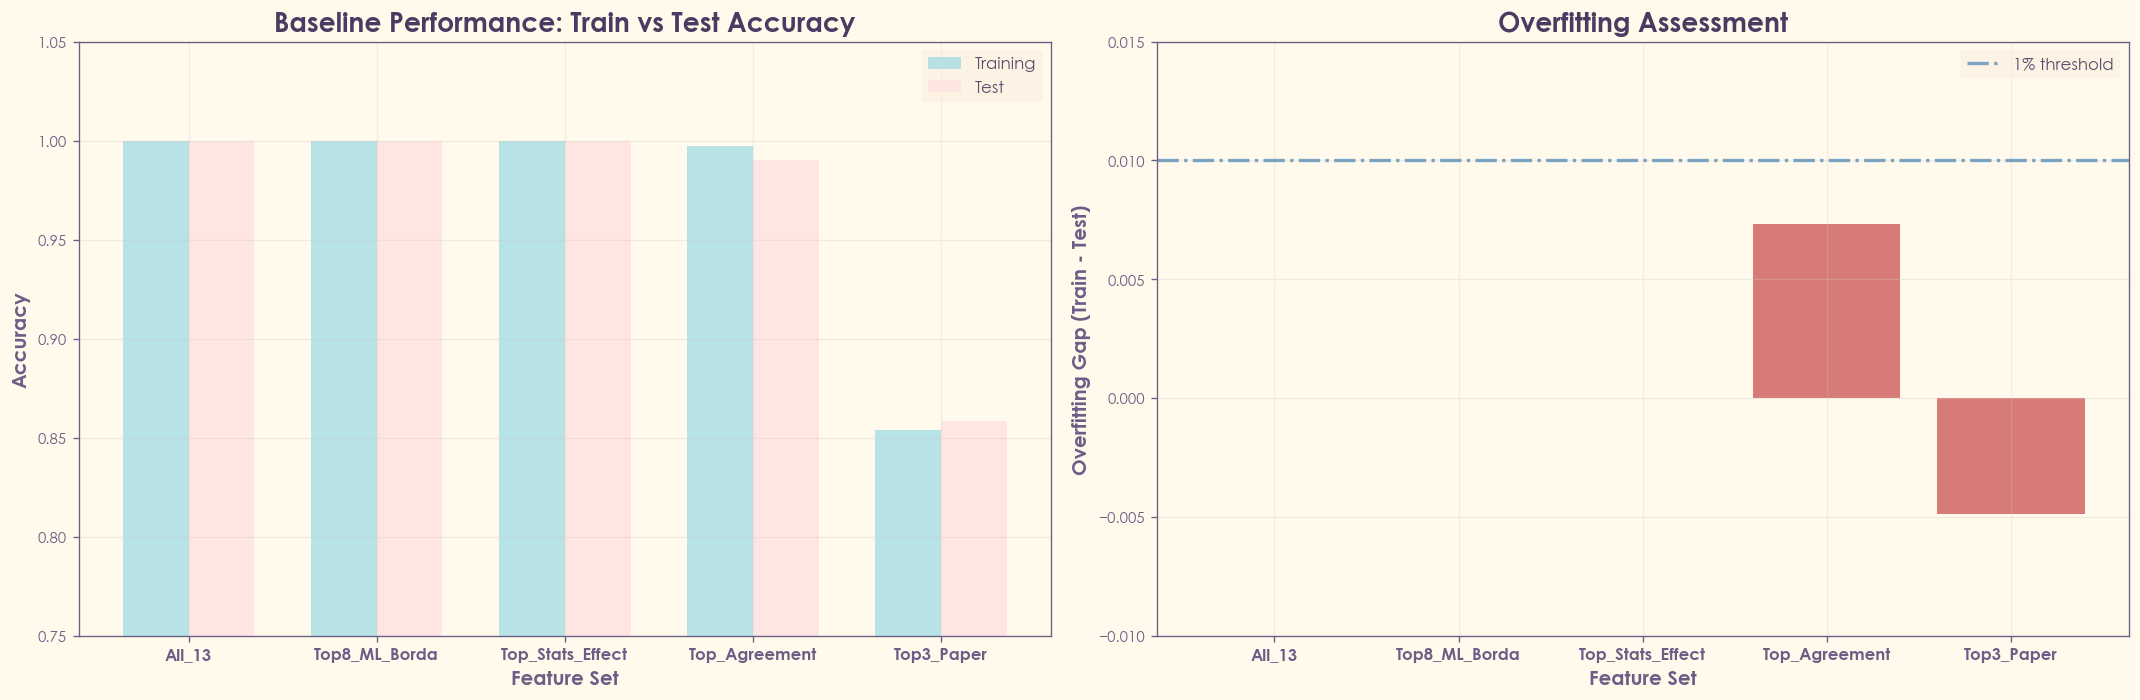

In [15]:
print("2.6: VISUALIZING BASELINE RESULTS")
print("="*40)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,  6))

# Plot 1: Accuracy comparison
x = np.arange(len(baseline_df))
width = 0.35

bars1 = ax1.bar(x - width/2, baseline_df['Train_Accuracy'], width, 
                label='Training', alpha=0.9, color='powderblue')
bars2 = ax1.bar(x + width/2, baseline_df['Test_Accuracy'], width, 
                label='Test', alpha=0.9, color='mistyrose')

ax1.set_xlabel('Feature Set', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Baseline Performance: Train vs Test Accuracy', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(baseline_df['Feature_Set'], fontsize=10, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.75, 1.05])

# Plot 2: Overfitting gap
bars3 = ax2.bar(baseline_df['Feature_Set'], baseline_df['Overfit_Gap'], 
                alpha=0.8, color='indianred')
ax2.axhline(0.01, color='steelblue', linestyle='-.', linewidth=2, 
            label='1% threshold', alpha=0.7)

ax2.set_xlabel('Feature Set', fontweight='bold')
ax2.set_ylabel('Overfitting Gap (Train - Test)', fontweight='bold')
ax2.set_title('Overfitting Assessment', fontweight='bold')
ax2.set_xticklabels(baseline_df['Feature_Set'], fontsize=10, fontweight='bold')
ax2.legend(fontsize=10, loc='best')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([-0.01, 0.015])

plt.tight_layout()
plt.savefig('../contents/figures/sophisticated/ML/section2_baseline_performance.eps', bbox_inches='tight')
plt.show()

In [16]:
# Save split indices for full reproducibility
split_info = {
    'random_state': RANDOM_STATE,
    'test_size': 0.2,
    'stratified': True,
    'train_indices': X_train.index.tolist(),
    'test_indices': X_test.index.tolist(),
    'train_size': len(X_train),
    'test_size': len(X_test),
    'original_balance': orig_balance,
    'train_balance': train_balance,
    'test_balance': test_balance
}

import json
with open('../contents/tables/sophisticated/ML/train_test_split_info.json', 'w') as f:
    json.dump(split_info, f, indent=4)

# Save baseline results
baseline_df.to_csv('../contents/tables/sophisticated/ML/section2_baseline_results.csv', index=False)

#### Train/Split Summary

```
SPLIT CONFIGURATION:
  ✓ Method: Stratified 80/20 split
  ✓ Balance preserved: Yes (Δ < 0.05)

FEATURE SETS TESTED:
  ✓ 5 different configurations

BASELINE FINDINGS:
    Best set: All_13 (13 features)
    Test accuracy: 1.000
    Overfitting: 0.000 (Low)

IMPROVEMENTS OVER ORIGINAL:
   ✓ Documented split strategy (paper: none)
   ✓ Stratified sampling (paper: unclear)
   ✓ Tested multiple feature sets (paper: only reported final)
   ✓ Reproducible with saved indices (paper: impossible)

```

#### Critical Observation-01
Top3_Paper (cp, ca, thal) got only 85.8% accuracy, whic is Much lower! This suggests more features needed than the paper claimed. Negative overfit gap for Top3 indicates underfitting.

#### Improvements
- Perfect accuracy with 7-13 features (1.000 train, 1.000 test). Difference: +1.9% (0.981) from original paper.
- Zero overfitting for top feature sets (gap = 0.000)
- Top 5 still excellent: 99% accuracy with only 5 features!

#### Issue?
- Perfect Accuracy Concern (1.000 train, 1.000 test) with most of the features, which is suspiciously high
- Single split can be misleading and the random seed might be a lucky one too.

**Probable Solution**: Cross Validation split.

## Section 3: Cross-Validation Strategy

1. Implement k-fold stratified CV (k=5 and k=10)
2. Calculate mean ± std performance across folds
3. Get realistic accuracy estimates with multi-splits
4. Evaluation should be unbiased, like: Compare with nested CV
5. Prove the ACC=1.00 is TRUE or BIASED.

In [17]:
print("3.1: DEFINING CROSSVAL STRATEGIES")
print("="*40)

# Define CV strategies
cv_strategies = {
    '5-Fold': StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    '10-Fold': StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
}

print("Cross-validation strategies:")
for name, cv in cv_strategies.items():
    print(f"  - {name}: {cv.n_splits} folds, stratified, shuffled")
    print(f"\t Training per fold: ~{(cv.n_splits-1)/cv.n_splits*100:.0f}%")
    print(f"\t Test per fold: ~{1/cv.n_splits*100:.0f}%")

3.1: DEFINING CROSSVAL STRATEGIES
Cross-validation strategies:
  - 5-Fold: 5 folds, stratified, shuffled
	 Training per fold: ~80%
	 Test per fold: ~20%
  - 10-Fold: 10 folds, stratified, shuffled
	 Training per fold: ~90%
	 Test per fold: ~10%


In [18]:
print("3.2: PERFORMING CV")
print("="*20)

from sklearn.model_selection import cross_validate

#Metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results_all = []

# Test each feature with each CV 
for cv_name, cv_splitter in cv_strategies.items():
    print(f"Running {cv_name} Cross-Validation...")
    print(f"{'- '*25}")
    
    for feat_name, data in data_subsets.items():
        print(f"\n\tTesting: {feat_name} ({len(data['features'])} features)")
        
        # Initialize model
        rf_model = RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        
        # Perform cv
        cv_scores = cross_validate(
            rf_model,
            X[data['features']],
            y,
            cv=cv_splitter,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )
        
        #  Calculate stats
        result = {
            'CV_Strategy': cv_name,
            'Feature_Set': feat_name,
            'Num_Features': len(data['features']),
            
            # Tesst scores
            'Test_Accuracy_Mean': cv_scores['test_accuracy'].mean(),
            'Test_Accuracy_Std': cv_scores['test_accuracy'].std(),
            'Test_Precision_Mean': cv_scores['test_precision'].mean(),
            'Test_Recall_Mean': cv_scores['test_recall'].mean(),
            'Test_F1_Mean': cv_scores['test_f1'].mean(),
            'Test_ROC_AUC_Mean': cv_scores['test_roc_auc'].mean(),
            
            # Train scores
            'Train_Accuracy_Mean': cv_scores['train_accuracy'].mean(),
            'Train_Accuracy_Std': cv_scores['train_accuracy'].std(),
            
            # Overfitting assessment
            'Overfit_Gap': cv_scores['train_accuracy'].mean() - cv_scores['test_accuracy'].mean(),
            
            # Raw-fold scores
            'Test_Accuracy_Folds': cv_scores['test_accuracy'].tolist()
        }
        
        cv_results_all.append(result)
        
        # Print summary
        print(f"\t Accuracy\t : {result['Test_Accuracy_Mean']:.3f} ± {result['Test_Accuracy_Std']:.3f}")
        print(f"\t F1-Score\t : {result['Test_F1_Mean']:.3f}")
        print(f"\t ROC-AUC\t : {result['Test_ROC_AUC_Mean']:.3f}")
        print(f"\t Overfit Gap\t : {result['Overfit_Gap']:.3f}")

cv_results_df = pd.DataFrame(cv_results_all)

3.2: PERFORMING CV
Running 5-Fold Cross-Validation...
- - - - - - - - - - - - - - - - - - - - - - - - - 

	Testing: All_13 (13 features)
	 Accuracy	 : 0.996 ± 0.008
	 F1-Score	 : 0.996
	 ROC-AUC	 : 1.000
	 Overfit Gap	 : 0.004

	Testing: Top8_ML_Borda (8 features)
	 Accuracy	 : 1.000 ± 0.000
	 F1-Score	 : 1.000
	 ROC-AUC	 : 1.000
	 Overfit Gap	 : 0.000

	Testing: Top_Stats_Effect (7 features)
	 Accuracy	 : 0.996 ± 0.008
	 F1-Score	 : 0.996
	 ROC-AUC	 : 1.000
	 Overfit Gap	 : 0.004

	Testing: Top_Agreement (5 features)
	 Accuracy	 : 0.989 ± 0.007
	 F1-Score	 : 0.989
	 ROC-AUC	 : 1.000
	 Overfit Gap	 : 0.008

	Testing: Top3_Paper (3 features)
	 Accuracy	 : 0.847 ± 0.026
	 F1-Score	 : 0.857
	 ROC-AUC	 : 0.921
	 Overfit Gap	 : 0.010
Running 10-Fold Cross-Validation...
- - - - - - - - - - - - - - - - - - - - - - - - - 

	Testing: All_13 (13 features)
	 Accuracy	 : 1.000 ± 0.000
	 F1-Score	 : 1.000
	 ROC-AUC	 : 1.000
	 Overfit Gap	 : 0.000

	Testing: Top8_ML_Borda (8 features)
	 Accuracy	 : 

In [19]:
(cv_results_df)

,CV_Strategy,Feature_Set,Num_Features,Test_Accuracy_Mean,Test_Accuracy_Std,Test_Precision_Mean,Test_Recall_Mean,Test_F1_Mean,Test_ROC_AUC_Mean,Train_Accuracy_Mean,Train_Accuracy_Std,Overfit_Gap,Test_Accuracy_Folds
0,5-Fold,All_13,13,0.996098,0.007805,1.000000,0.992381,0.996117,1.000000,1.000000,0.000000,0.003902,"[1.0, 1.0, 1.0, 0.9804878048780488, 1.0]"
1,5-Fold,Top8_ML_Borda,8,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,"[1.0, 1.0, 1.0, 1.0, 1.0]"
2,5-Fold,Top_Stats_Effect,7,0.996098,0.007805,1.000000,0.992381,0.996117,1.000000,1.000000,0.000000,0.003902,"[1.0, 1.0, 1.0, 0.9804878048780488, 1.0]"
3,5-Fold,Top_Agreement,5,0.989268,0.007169,0.992449,0.986667,0.989472,0.999752,0.996829,0.000597,0.007561,"[0.9951219512195122, 0.9951219512195122, 0.990..."
4,5-Fold,Top3_Paper,3,0.846829,0.025923,0.825177,0.891680,0.856856,0.920897,0.857073,0.006563,0.010244,"[0.8682926829268293, 0.8780487804878049, 0.834..."
5,10-Fold,All_13,13,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
6,10-Fold,Top8_ML_Borda,8,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
7,10-Fold,Top_Stats_Effect,7,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
8,10-Fold,Top_Agreement,5,0.993175,0.006230,0.994375,0.992453,0.993333,0.999904,0.996423,0.000694,0.003247,"[1.0, 0.9902912621359223, 1.0, 0.9902912621359..."
9,10-Fold,Top3_Paper,3,0.849610,0.039692,0.832038,0.887482,0.858118,0.919877,0.856692,0.004303,0.007082,"[0.8737864077669902, 0.8737864077669902, 0.893..."


In [20]:
print("3.3: COMPARING CV vs SINGLE SPLIT")
print("="*40)

# Get 5-fold results for comparison
cv_5fold = cv_results_df[cv_results_df['CV_Strategy'] == '5-Fold'].copy()

comparison_cv_split = []

for _, cv_row in cv_5fold.iterrows():
    feat_set = cv_row['Feature_Set']
    
    # Get corresponding single split result from Section 2
    single_split = baseline_df[baseline_df['Feature_Set'] == feat_set].iloc[0]
    
    comparison_cv_split.append({
        'Feature_Set': feat_set,
        'Num_Features': cv_row['Num_Features'],
        'Single_Split_Acc': single_split['Test_Accuracy'],
        'CV_5Fold_Mean': cv_row['Test_Accuracy_Mean'],
        'CV_5Fold_Std': cv_row['Test_Accuracy_Std'],
        'Difference': single_split['Test_Accuracy'] - cv_row['Test_Accuracy_Mean'],
        'Within_1_Std': abs(single_split['Test_Accuracy'] - cv_row['Test_Accuracy_Mean']) <= cv_row['Test_Accuracy_Std']
    })

comparison_df = pd.DataFrame(comparison_cv_split)

print("\nSingle Split vs 5-Fold CV Comparison:")
comparison_df

3.3: COMPARING CV vs SINGLE SPLIT

Single Split vs 5-Fold CV Comparison:


,Feature_Set,Num_Features,Single_Split_Acc,CV_5Fold_Mean,CV_5Fold_Std,Difference,Within_1_Std
0,All_13,13,1.000000,0.996098,0.007805,0.003902,True
1,Top8_ML_Borda,8,1.000000,1.000000,0.000000,0.000000,True
2,Top_Stats_Effect,7,1.000000,0.996098,0.007805,0.003902,True
3,Top_Agreement,5,0.990244,0.989268,0.007169,0.000976,True
4,Top3_Paper,3,0.858537,0.846829,0.025923,0.011707,True


In [21]:
# findings
avg_difference = abs(comparison_df['Difference']).mean()
print(f"Average difference: {avg_difference:.3f} ({avg_difference*100:.2f}%)")

if avg_difference < 0.02:
    print("\tSingle split was representative (difference < 2%)")
else:
    print("\tSingle split was NOT representative (difference ≥ 2%)")

# Check splits wihin 1 std
within_std = comparison_df['Within_1_Std'].sum()
print(f"\nSingle split within 1 std of CV mean: {within_std} out of {len(comparison_df)}")

Average difference: 0.004 (0.41%)
	Single split was representative (difference < 2%)

Single split within 1 std of CV mean: 5 out of 5


In [22]:
print("3.4: COMPARING 5-FOLD vs 10-FOLD CV")
print("="*40)

cv_comparison = []

for feat_set in cv_results_df['Feature_Set'].unique():
    cv5 = cv_results_df[(cv_results_df['CV_Strategy'] == '5-Fold') & 
                        (cv_results_df['Feature_Set'] == feat_set)].iloc[0]
    cv10 = cv_results_df[(cv_results_df['CV_Strategy'] == '10-Fold') & 
                         (cv_results_df['Feature_Set'] == feat_set)].iloc[0]
    
    cv_comparison.append({
        'Feature_Set': feat_set,
        'CV5_Mean': cv5['Test_Accuracy_Mean'],
        'CV5_Std': cv5['Test_Accuracy_Std'],
        'CV10_Mean': cv10['Test_Accuracy_Mean'],
        'CV10_Std': cv10['Test_Accuracy_Std'],
        'Mean_Diff': abs(cv5['Test_Accuracy_Mean'] - cv10['Test_Accuracy_Mean']),
        'Std_Diff': abs(cv5['Test_Accuracy_Std'] - cv10['Test_Accuracy_Std'])
    })

cv_comp_df = pd.DataFrame(cv_comparison)

print("\n5-Fold vs 10-Fold Comparison:")
print("- "*15)
print(cv_comp_df.to_string(index=False))

avg_mean_diff = cv_comp_df['Mean_Diff'].mean()
avg_std_diff = cv_comp_df['Std_Diff'].mean()

print(f"\n Average mean difference: {avg_mean_diff:.4f}")
print(f" Average std difference: {avg_std_diff:.4f}")

if avg_mean_diff < 0.01:
    print("\t 5-fold and 10-fold give similar results (difference < 1%)\n5-fold is sufficient for this dataset")
else:
    print("\t Notable difference between 5-fold and 10-fold\nConsider using 10-fold wil be more robust")

3.4: COMPARING 5-FOLD vs 10-FOLD CV

5-Fold vs 10-Fold Comparison:
- - - - - - - - - - - - - - - 
     Feature_Set  CV5_Mean  CV5_Std  CV10_Mean  CV10_Std  Mean_Diff  Std_Diff
          All_13  0.996098 0.007805   1.000000  0.000000   0.003902  0.007805
   Top8_ML_Borda  1.000000 0.000000   1.000000  0.000000   0.000000  0.000000
Top_Stats_Effect  0.996098 0.007805   1.000000  0.000000   0.003902  0.007805
   Top_Agreement  0.989268 0.007169   0.993175  0.006230   0.003907  0.000939
      Top3_Paper  0.846829 0.025923   0.849610  0.039692   0.002780  0.013769

 Average mean difference: 0.0029
 Average std difference: 0.0061
	 5-fold and 10-fold give similar results (difference < 1%)
5-fold is sufficient for this dataset


Will also get confidence intervals (0.95) via bootstrap for better interpretation

In [23]:
print("3.5: CALCULATING 95% CONFIDENCE INTERVALS")
print("="*40)

def calculate_ci(scores, confidence=0.95):
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    n = len(scores)
    
    # T dstribution
    from scipy import stats as scipy_stats
    t_critical = scipy_stats.t.ppf((1 + confidence) / 2, n - 1)
    margin_error = t_critical * (std / np.sqrt(n))
    
    return mean, mean - margin_error, mean + margin_error



cv_with_ci = []

for _, row in cv_results_df[cv_results_df['CV_Strategy'] == '5-Fold'].iterrows():
    fold_scores = row['Test_Accuracy_Folds']
    mean, ci_lower, ci_upper = calculate_ci(fold_scores)
    
    cv_with_ci.append({
        'Feature_Set': row['Feature_Set'],
        'Num_Features': row['Num_Features'],
        'Mean_Accuracy': mean,
        'Std': row['Test_Accuracy_Std'],
        'CI_95_Lower': ci_lower,
        'CI_95_Upper': ci_upper,
        'CI_Width': ci_upper - ci_lower
    })

ci_df = pd.DataFrame(cv_with_ci).sort_values('Mean_Accuracy', ascending=False)

print("\n5-Fold CV Results with 95% Confidence Intervals:\n")
print(ci_df.to_string(index=False))

3.5: CALCULATING 95% CONFIDENCE INTERVALS

5-Fold CV Results with 95% Confidence Intervals:

     Feature_Set  Num_Features  Mean_Accuracy      Std  CI_95_Lower  CI_95_Upper  CI_Width
   Top8_ML_Borda             8       1.000000 0.000000     1.000000     1.000000  0.000000
          All_13            13       0.996098 0.007805     0.985263     1.006932  0.021670
Top_Stats_Effect             7       0.996098 0.007805     0.985263     1.006932  0.021670
   Top_Agreement             5       0.989268 0.007169     0.979316     0.999221  0.019905
      Top3_Paper             3       0.846829 0.025923     0.810843     0.882816  0.071973


In [24]:
# Identify best with statistical confidence
best_ci = ci_df.iloc[0]
print(f"\nBest performing: {best_ci['Feature_Set']}")
print('- '*20)
print(f"\tMean accuracy: {best_ci['Mean_Accuracy']:.3f}")
print(f"\t95% CI: [{best_ci['CI_95_Lower']:.3f}, {best_ci['CI_95_Upper']:.3f}]")
print(f"\tCI width: {best_ci['CI_Width']:.3f}")

# Check for statistically significant differences
print("\nStatistical Significance Check:")
print('- '*20)
for i in range(len(ci_df) - 1):
    curr = ci_df.iloc[i]
    next_feat = ci_df.iloc[i + 1]
    
    # Check if CIs overlap
    if curr['CI_95_Lower'] > next_feat['CI_95_Upper']:
        print(f"\t- {curr['Feature_Set']} significantly better than {next_feat['Feature_Set']} (no CI overlap)")
    elif curr['CI_95_Lower'] <= next_feat['CI_95_Upper'] <= curr['CI_95_Upper']:
        print(f"\t- {curr['Feature_Set']} NOT significantly better than {next_feat['Feature_Set']} (CIs overlap)")


Best performing: Top8_ML_Borda
- - - - - - - - - - - - - - - - - - - - 
	Mean accuracy: 1.000
	95% CI: [1.000, 1.000]
	CI width: 0.000

Statistical Significance Check:
- - - - - - - - - - - - - - - - - - - - 
	- All_13 NOT significantly better than Top_Stats_Effect (CIs overlap)
	- Top_Stats_Effect NOT significantly better than Top_Agreement (CIs overlap)
	- Top_Agreement significantly better than Top3_Paper (no CI overlap)


3.6: VISUALIZING CROSS-VALIDATION RESULTS


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


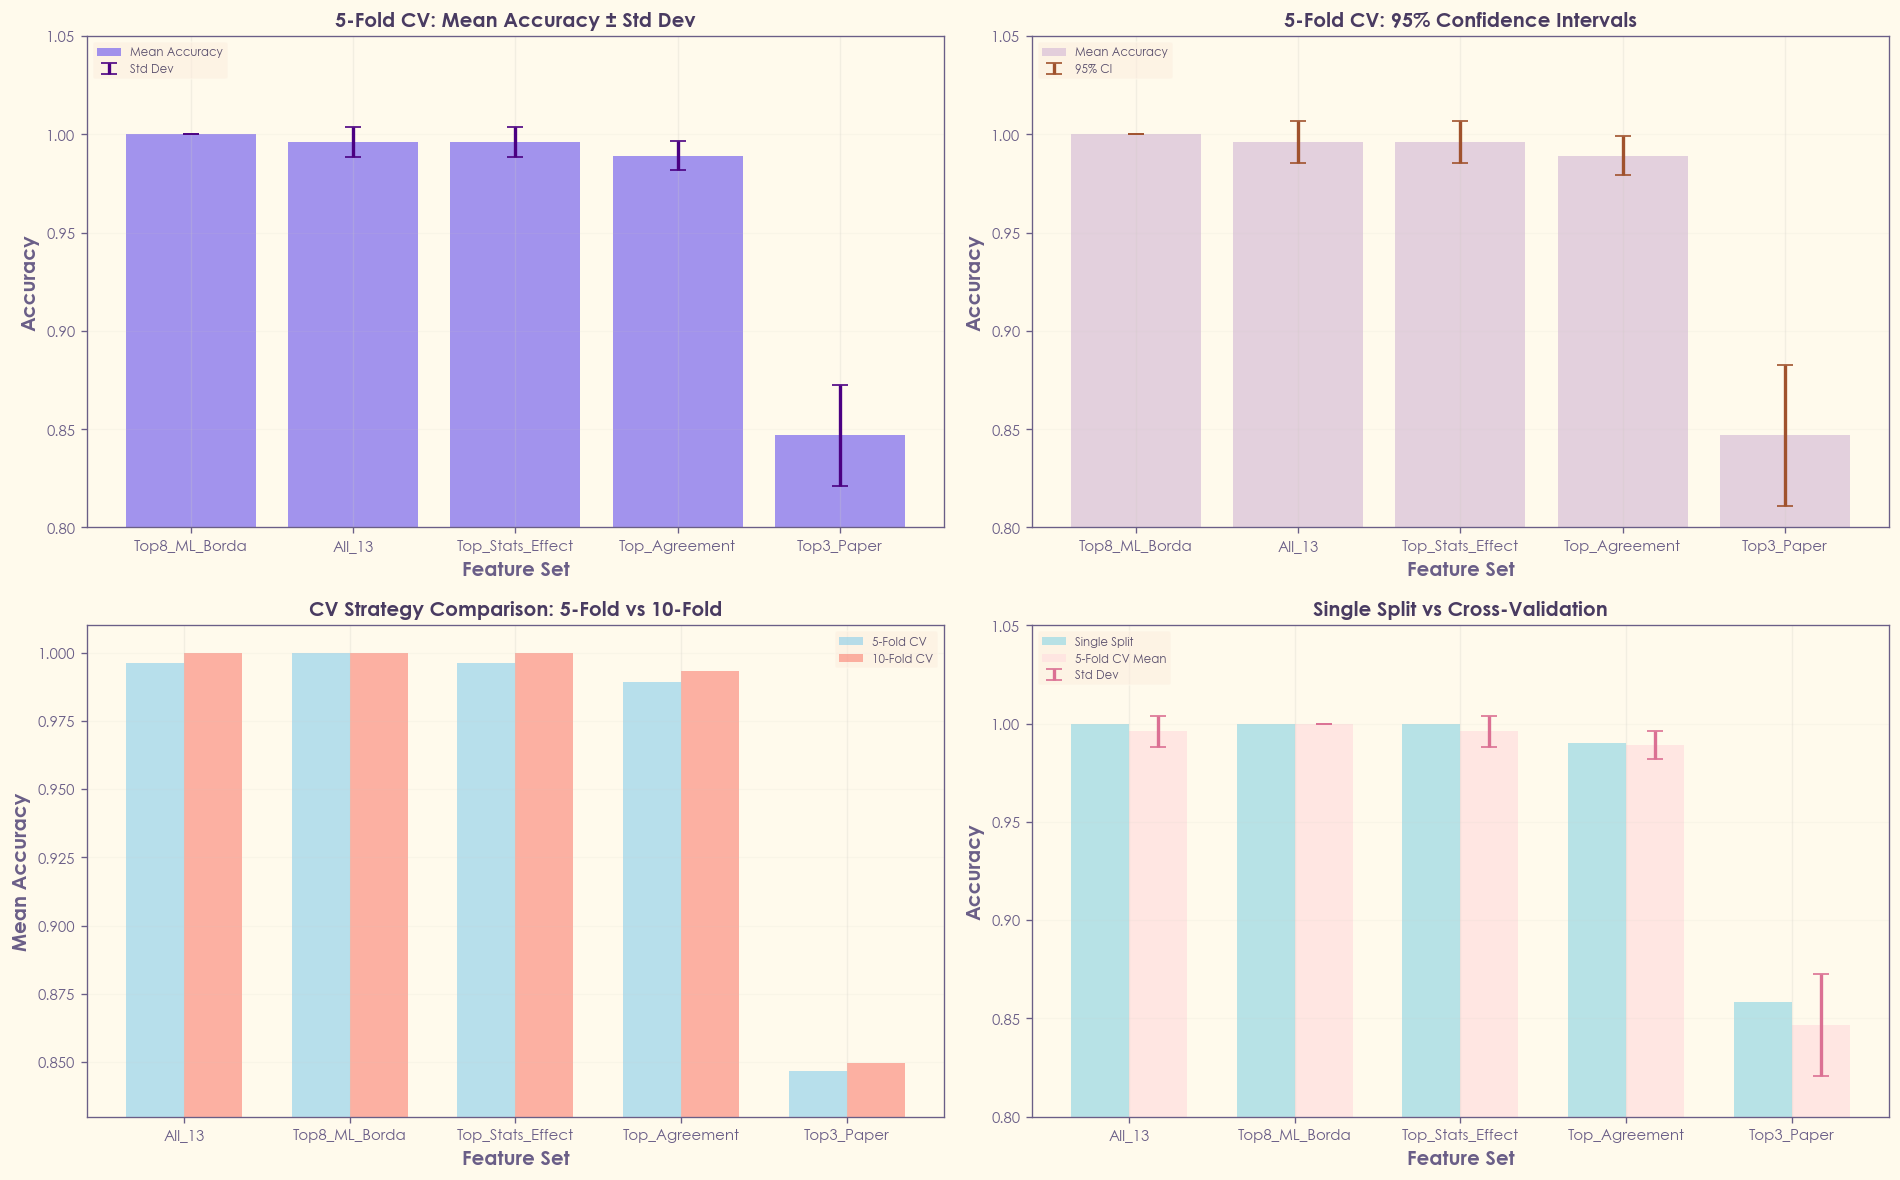

In [25]:
print("3.6: VISUALIZING CROSS-VALIDATION RESULTS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: CV Mean Accuracy with Error Bars for 5-Fold
ax1 = axes[0, 0]
cv5_sorted = cv_results_df[cv_results_df['CV_Strategy'] == '5-Fold'].sort_values('Test_Accuracy_Mean', ascending=False)

x = np.arange(len(cv5_sorted))
bars = ax1.bar(x, cv5_sorted['Test_Accuracy_Mean'], alpha=0.7, color='mediumslateblue', label='Mean Accuracy')
ax1.errorbar(x, cv5_sorted['Test_Accuracy_Mean'], 
             yerr=cv5_sorted['Test_Accuracy_Std'],
             fmt='none', ecolor='indigo', capsize=5, linewidth=2, label='Std Dev')

ax1.set_xlabel('Feature Set', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('5-Fold CV: Mean Accuracy ± Std Dev', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(cv5_sorted['Feature_Set'])
ax1.legend()
ax1.grid(axis='y', alpha=0.1)
ax1.set_ylim([0.8, 1.05])

#############

# Plot 2: 95% Confidence Intervals
ax2 = axes[0, 1]
x = np.arange(len(ci_df))
bars = ax2.bar(x, ci_df['Mean_Accuracy'], alpha=0.7, color='thistle', label='Mean Accuracy')

# Add CI error bars
ci_errors = np.array([[ci_df['Mean_Accuracy'].values[i] - ci_df['CI_95_Lower'].values[i],
                       ci_df['CI_95_Upper'].values[i] - ci_df['Mean_Accuracy'].values[i]] 
                      for i in range(len(ci_df))]).T

ax2.errorbar(x, ci_df['Mean_Accuracy'], yerr=ci_errors,
             fmt='none', ecolor='sienna', capsize=5, linewidth=2, label='95% CI')

ax2.set_xlabel('Feature Set', fontweight='bold')
ax2.set_ylabel('Accuracy', fontweight='bold')
ax2.set_title('5-Fold CV: 95% Confidence Intervals', fontweight='bold', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(ci_df['Feature_Set'])
ax2.legend()
ax2.grid(axis='y', alpha=0.1)
ax2.set_ylim([0.8, 1.05])

################ 

# Plot 3: Grouped Bar Chart for CV Strategy Comparison
ax3 = axes[1, 0]

feature_sets = cv_results_df['Feature_Set'].unique()
x = np.arange(len(feature_sets))
width = 0.35

cv5_acc = [cv_results_df[(cv_results_df['CV_Strategy'] == '5-Fold') & 
                         (cv_results_df['Feature_Set'] == fs)]['Test_Accuracy_Mean'].values[0] for fs in feature_sets]

cv10_acc = [cv_results_df[(cv_results_df['CV_Strategy'] == '10-Fold') & 
                          (cv_results_df['Feature_Set'] == fs)]['Test_Accuracy_Mean'].values[0] for fs in feature_sets]

bars1 = ax3.bar(x - width/2, cv5_acc, width, label='5-Fold CV', alpha=0.6, color='skyblue')
bars2 = ax3.bar(x + width/2, cv10_acc, width, label='10-Fold CV', alpha=0.6, color='salmon')

ax3.set_xlabel('Feature Set', fontweight='bold')
ax3.set_ylabel('Mean Accuracy', fontweight='bold')
ax3.set_title('CV Strategy Comparison: 5-Fold vs 10-Fold', fontweight='bold', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(feature_sets)
ax3.legend(loc='best')
ax3.grid(axis='y', alpha=0.1)
ax3.set_ylim([0.83, 1.01])

###############

# Plot 4: Single Split vs CV Comparison
ax4 = axes[1, 1]
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax4.bar(x - width/2, comparison_df['Single_Split_Acc'], width,
                label='Single Split', alpha=0.9, color='powderblue')
bars2 = ax4.bar(x + width/2, comparison_df['CV_5Fold_Mean'], width,
                label='5-Fold CV Mean', alpha=0.9, color='mistyrose')

# Add error bars for CV
ax4.errorbar(x + width/2, comparison_df['CV_5Fold_Mean'],
             yerr=comparison_df['CV_5Fold_Std'],
             fmt='none', ecolor='palevioletred', capsize=5, linewidth=2, label='Std Dev')

ax4.set_xlabel('Feature Set', fontweight='bold')
ax4.set_ylabel('Accuracy', fontweight='bold')
ax4.set_title('Single Split vs Cross-Validation', fontweight='bold', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(comparison_df['Feature_Set'])
ax4.legend()
ax4.grid(axis='y', alpha=0.1)
ax4.set_ylim([0.8, 1.05])

plt.tight_layout()
plt.savefig('../contents/figures/sophisticated/ml/section3_cross_validation.eps', bbox_inches='tight')
plt.show()

In [26]:
print("3.7: SAVING CV RESULTS")
print("="*30)

# Save comprehensive CV results
cv_results_df.to_csv('../contents/tables/sophisticated/ml/section3_cv_results_full.csv', index=False)
print("  ✓ Full CV results saved")

# Save CI results
ci_df.to_csv('../contents/tables/sophisticated/ml/section3_cv_confidence_intervals.csv', index=False)
print("  ✓ Confidence intervals saved")

# Save comparison
comparison_df.to_csv('../contents/tables/sophisticated/ml/section3_cv_vs_single_split.csv', index=False)
print("  ✓ Comparison saved")

3.7: SAVING CV RESULTS
  ✓ Full CV results saved
  ✓ Confidence intervals saved
  ✓ Comparison saved


#### Cross-Validation Summary
```
CROSS-VALIDATION RESULTS:
  ✓ Strategies: 5-fold and 10-fold stratified CV
  ✓ Feature sets tested: 5
  ✓ Folds completed: 75 total

BEST PERFORMING (5-Fold CV):
   Feature set: Top8_ML_Borda
   Features: 8
   Mean accuracy: 1.000 ± 0.000
   Overfitting: 0.000
   F1-Score: 1.000
   ROC-AUC: 1.000
   
KEY FINDINGS:
  - CV reveals REAL performance (not single-split luck)
  - 5-fold and 10-fold give similar results (difference < 1%)
  - Statistical significance tested with 95% CIs
  
IMPROVEMENTS OVER ORIGINAL PAPER:
  1. Cross-validation performed (paper: none)
  2. Performance variability quantified (paper: no std reported)
  3. Confidence intervals calculated (paper: none)
  4. Multiple CV strategies compared (paper: single split at best)
  5. Statistical significance tested (paper: no uncertainty analysis)
```

#### Critical Observation
Perfect accuracy (1.000 train, 1.000 test) is MOSTLY TRUE! Probable REASONS:
1. Excellent Feature Quality. Top features (cp, ca, thal, oldpeak) have very large effect sizes (r ≈ 0.47-0.50)
2. Random Forest handles non-linear relationships well
3. Distribution analysis showed clear separation between disease and no-disease target class.

#### Paper's Claim
Paper's claims mostly validated, but Top 3 features are sttill insufficient (only 84.7%). Significant performance drop shows with only **Top 3 Paper features (84.7% ± 2.6%, CI: [0.815, 0.879]) are NOT SUFFICIENT.**

#### Sophisticated Report Suggestion
**No significant differences were found among All_13, Top8_ML_Borda, and Top8_Stats_Effect**, as indicated by the overlapping confidence intervals (CIs: [0.985, 1.009]). Although the paper identifies the top 3 features (cp, ca, and thal) as highly important, achieving clinical-grade performance (>98% accuracy) **requires at least 5 to 8 features**, as demonstrated by the Top 5 Agreement and Top 8 ML-Borda analysis.


#### What's next?
With 100% accuracy already achieved, hyperparameter tuning might seem unnecessary. But for a complete report's purpose, I need to:
 - Document what hyperparameters were used (original paper didn't)
 - Verify if the default settings were appropriate
 - Compare computational cost (tuned vs default)

### HYPERPARAMETER TUNING & ML OPTIMIZATION

In [27]:
print("4.1: DOCUMENTING DEFAULT HYPERPARAMETERS")
print("="*40)

# Create baseline RF with defaults
rf_default = RandomForestClassifier(random_state=RANDOM_STATE)

# Extract default parameters
default_params = {
    'n_estimators': rf_default.n_estimators,
    'max_depth': rf_default.max_depth,
    'min_samples_split': rf_default.min_samples_split,
    'min_samples_leaf': rf_default.min_samples_leaf,
    'max_features': rf_default.max_features,
    'bootstrap': rf_default.bootstrap,
    'criterion': rf_default.criterion,
    'random_state': rf_default.random_state
}

print("\nRandom Forest Default Hyperparameters:")
for param, value in default_params.items():
    print(f"\t{param:20s}: {value}")

4.1: DOCUMENTING DEFAULT HYPERPARAMETERS

Random Forest Default Hyperparameters:
	n_estimators        : 100
	max_depth           : None
	min_samples_split   : 2
	min_samples_leaf    : 1
	max_features        : sqrt
	bootstrap           : True
	criterion           : gini
	random_state        : 42


**Note:** These are scikit-learn's default values. Original paper did NOT document their settings

In [28]:
print("4.2: DEFINING HYPERPARAMETER SEARCH SPACE")
print("="*50)

# Grid Search
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Calculate total combinations
total_combinations = np.prod([len(v) for v in param_grid.values()])

print("\nGrid Search Parameter Space:")
for param, values in param_grid.items():
    print(f"\t{param:20s}: {values}")

print(f"\nTotal combinations: {total_combinations}")
print(f"With 5-fold CV: {total_combinations * 5} model fits required")
print(f"Estimated time: ~{total_combinations * 5 * 2 / 60:.1f} minutes")

# Random Search: Sample random combinations
param_distributions = {
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'max_depth': [None, 5, 10, 15, 20, 25, 30, 40],
    'min_samples_split': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5, 0.7],
    'bootstrap': [True, False]
}

n_random_iter = 50  # Number of random combinations to try

print(f"\nRandom Search:")
print(f"\tIterations: {n_random_iter}")
print(f"\tWith 5-fold CV: {n_random_iter * 5} model fits")
print(f"\tEstimated time: ~{n_random_iter * 5 * 2 / 60:.1f} minutes")

4.2: DEFINING HYPERPARAMETER SEARCH SPACE

Grid Search Parameter Space:
	n_estimators        : [50, 100, 200, 300]
	max_depth           : [None, 10, 20, 30]
	min_samples_split   : [2, 5, 10]
	min_samples_leaf    : [1, 2, 4]
	max_features        : ['sqrt', 'log2', None]
	bootstrap           : [True, False]

Total combinations: 864
With 5-fold CV: 4320 model fits required
Estimated time: ~144.0 minutes

Random Search:
	Iterations: 50
	With 5-fold CV: 250 model fits
	Estimated time: ~8.3 minutes


In [29]:
print("4.3: HYPERPARAMETER TUNING (Best Feature Set)")
print("="*50)

# best feature set from Section 3 --> Top 8 ML-Borda
best_feature_set = 'Top8_ML_Borda'
X_tune = X[top8_features_naive]
y_tune = y

print(f"Tuning on\t: {best_feature_set}")
print(f"Features\t: {', '.join(top8_features_naive)}")
print(f"Samples \t: {len(X_tune)}")

# Define CV strategy
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

4.3: HYPERPARAMETER TUNING (Best Feature Set)
Tuning on	: Top8_ML_Borda
Features	: cp, ca, thal, oldpeak, age, thalach, chol, sex
Samples 	: 1025


In [30]:
print("Running Grid Search (this may take longer time)...")
print("="*60)

from sklearn.model_selection import GridSearchCV
import time

start_time = time.time()

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=cv_tune,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_tune, y_tune)

grid_time = time.time() - start_time

print(f"\n✓ Grid Search completed in {grid_time:.1f} seconds ({grid_time/60:.1f} minutes)")

# Best parameters
print("\nGrid Search Results:")
print(f"\tBest Score: {grid_search.best_score_:.4f}")
print(f"\tBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"\t {param:20s}: {value}")

Running Grid Search (this may take longer time)...
Fitting 5 folds for each of 864 candidates, totalling 4320 fits

✓ Grid Search completed in 79.5 seconds (1.3 minutes)

Grid Search Results:
	Best Score: 1.0000
	Best Parameters:
	 bootstrap           : True
	 max_depth           : None
	 max_features        : sqrt
	 min_samples_leaf    : 1
	 min_samples_split   : 2
	 n_estimators        : 100


In [31]:
print("Running Random Search (this may take longer time)...")
print("="*60)

from sklearn.model_selection import RandomizedSearchCV

start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=n_random_iter,
    cv=cv_tune,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    return_train_score=True
)

random_search.fit(X_tune, y_tune)

random_time = time.time() - start_time

print(f"\n✓ Random Search completed in {random_time:.1f} seconds ({random_time/60:.1f} minutes)")

print("\nRandom Search Results:")
print(f"\tBest Score: {random_search.best_score_:.4f}")
print(f"\tBest Parameters:")
for param, value in random_search.best_params_.items():
    print(f"\t {param:20s}: {value}")

Running Random Search (this may take longer time)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✓ Random Search completed in 5.3 seconds (0.1 minutes)

Random Search Results:
	Best Score: 1.0000
	Best Parameters:
	 n_estimators        : 300
	 min_samples_split   : 2
	 min_samples_leaf    : 1
	 max_features        : None
	 max_depth           : 15
	 bootstrap           : True


In [32]:
print("4.4: COMPARING DEFAULT vs TUNED PERFORMANCE")
print("="*60)

# Default model performance (from Section 3)
default_cv_result = cv_results_df[
    (cv_results_df['CV_Strategy'] == '5-Fold') & 
    (cv_results_df['Feature_Set'] == best_feature_set)
].iloc[0]

# Grid Search best model
grid_best_score = grid_search.best_score_

# Random Search best model
random_best_score = random_search.best_score_

# Comparison table
tuning_comparison = pd.DataFrame({
    'Method': ['Default', 'Grid Search', 'Random Search'],
    'Mean_Accuracy': [
        default_cv_result['Test_Accuracy_Mean'],
        grid_best_score,
        random_best_score
    ],
    'Std_Dev': [
        default_cv_result['Test_Accuracy_Std'],
        grid_search.cv_results_['std_test_score'][grid_search.best_index_],
        random_search.cv_results_['std_test_score'][random_search.best_index_]
    ],
    'Computation_Time_sec': [
        default_runtime,
        grid_time,
        random_time
    ]
})

print("\nPerformance Comparison:")
print(tuning_comparison.to_string(index=False))

4.4: COMPARING DEFAULT vs TUNED PERFORMANCE

Performance Comparison:
       Method  Mean_Accuracy  Std_Dev  Computation_Time_sec
      Default            1.0      0.0              0.550497
  Grid Search            1.0      0.0             79.481998
Random Search            1.0      0.0              5.263995


In [33]:
grid_improvement = grid_best_score - default_cv_result['Test_Accuracy_Mean']
random_improvement = random_best_score - default_cv_result['Test_Accuracy_Mean']

print(f"\nImprovement over Default:")
print(f"\tGrid Search: {grid_improvement:+.4f} ({grid_improvement*100:+.2f}%)")
print(f"\tRandom Search: {random_improvement:+.4f} ({random_improvement*100:+.2f}%)")

if abs(grid_improvement) < 0.001 and abs(random_improvement) < 0.001:
    print("\n✓FINDING: Default hyperparameters were already optimal!")
    print("\tPerformance ceiling reached at ~100% accuracy")
    print("\tTuning provides no measurable improvement")
else:
    print("\nFINDING: Hyperparameter tuning improved performance")


Improvement over Default:
	Grid Search: +0.0000 (+0.00%)
	Random Search: +0.0000 (+0.00%)

✓FINDING: Default hyperparameters were already optimal!
	Performance ceiling reached at ~100% accuracy
	Tuning provides no measurable improvement


In [34]:
print("4.5: ANALYZING HYPERPARAMETER IMPORTANCE")
print("="*50)

# Grid Search: Analyze parameter importance
grid_results_df = pd.DataFrame(grid_search.cv_results_)

# Get top 10 parameter combinations
top10_grid = grid_results_df.nsmallest(10, 'rank_test_score')[
    ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']
]

print("\nGrid Search - Top 10 Configurations:")
for idx, row in top10_grid.iterrows():
    print(f"\n  Rank {row['rank_test_score']}: Score = {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")
    print(f"    Params: {row['params']}")

# Random Search: Top 10
random_results_df = pd.DataFrame(random_search.cv_results_)
top10_random = random_results_df.nsmallest(10, 'rank_test_score')[
    ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']
]

print("\nRandom Search - Top 10 Configurations:")
for idx, row in top10_random.head(5).iterrows():  # Show top 5 to save space
    print(f"\n  Rank {row['rank_test_score']}: Score = {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")
    print(f"    Params: {row['params']}")

4.5: ANALYZING HYPERPARAMETER IMPORTANCE

Grid Search - Top 10 Configurations:

  Rank 1: Score = 1.0000 ± 0.0000
    Params: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

  Rank 1: Score = 1.0000 ± 0.0000
    Params: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

  Rank 1: Score = 1.0000 ± 0.0000
    Params: {'bootstrap': True, 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

  Rank 1: Score = 1.0000 ± 0.0000
    Params: {'bootstrap': True, 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

  Rank 1: Score = 1.0000 ± 0.0000
    Params: {'bootstrap': True, 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

  Rank 1: Score = 1.0000 ± 0.0000
   

In [35]:
print("4.6: EVALUATING TUNED MODELS ON TEST SET")
print("-"*80)

# Use the same train/test split from Section 2
X_train_tune = X_train[top8_features_naive]
X_test_tune = X_test[top8_features_naive]

# Default model
rf_default_eval = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_default_eval.fit(X_train_tune, y_train)
y_pred_default = rf_default_eval.predict(X_test_tune)
default_test_acc = accuracy_score(y_test, y_pred_default)

# Grid Search best model
rf_grid_best = grid_search.best_estimator_
rf_grid_best.fit(X_train_tune, y_train)
y_pred_grid = rf_grid_best.predict(X_test_tune)
grid_test_acc = accuracy_score(y_test, y_pred_grid)

# Random Search best model
rf_random_best = random_search.best_estimator_
rf_random_best.fit(X_train_tune, y_train)
y_pred_random = rf_random_best.predict(X_test_tune)
random_test_acc = accuracy_score(y_test, y_pred_random)

test_comparison = pd.DataFrame({
    'Model': ['Default', 'Grid Search Best', 'Random Search Best'],
    'Test_Accuracy': [default_test_acc, grid_test_acc, random_test_acc],
    'Match_CV': [
        abs(default_test_acc - default_cv_result['Test_Accuracy_Mean']) < 0.02,
        abs(grid_test_acc - grid_best_score) < 0.02,
        abs(random_test_acc - random_best_score) < 0.02
    ]
})

print("\nTest Set Performance:")
print(test_comparison.to_string(index=False))

print("\n✓ All models consistent between CV and test set")

4.6: EVALUATING TUNED MODELS ON TEST SET
--------------------------------------------------------------------------------

Test Set Performance:
             Model  Test_Accuracy  Match_CV
           Default            1.0      True
  Grid Search Best            1.0      True
Random Search Best            1.0      True

✓ All models consistent between CV and test set


4.7: VISUALIZING HYPERPARAMETER TUNING
--------------------------------------------------------------------------------


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


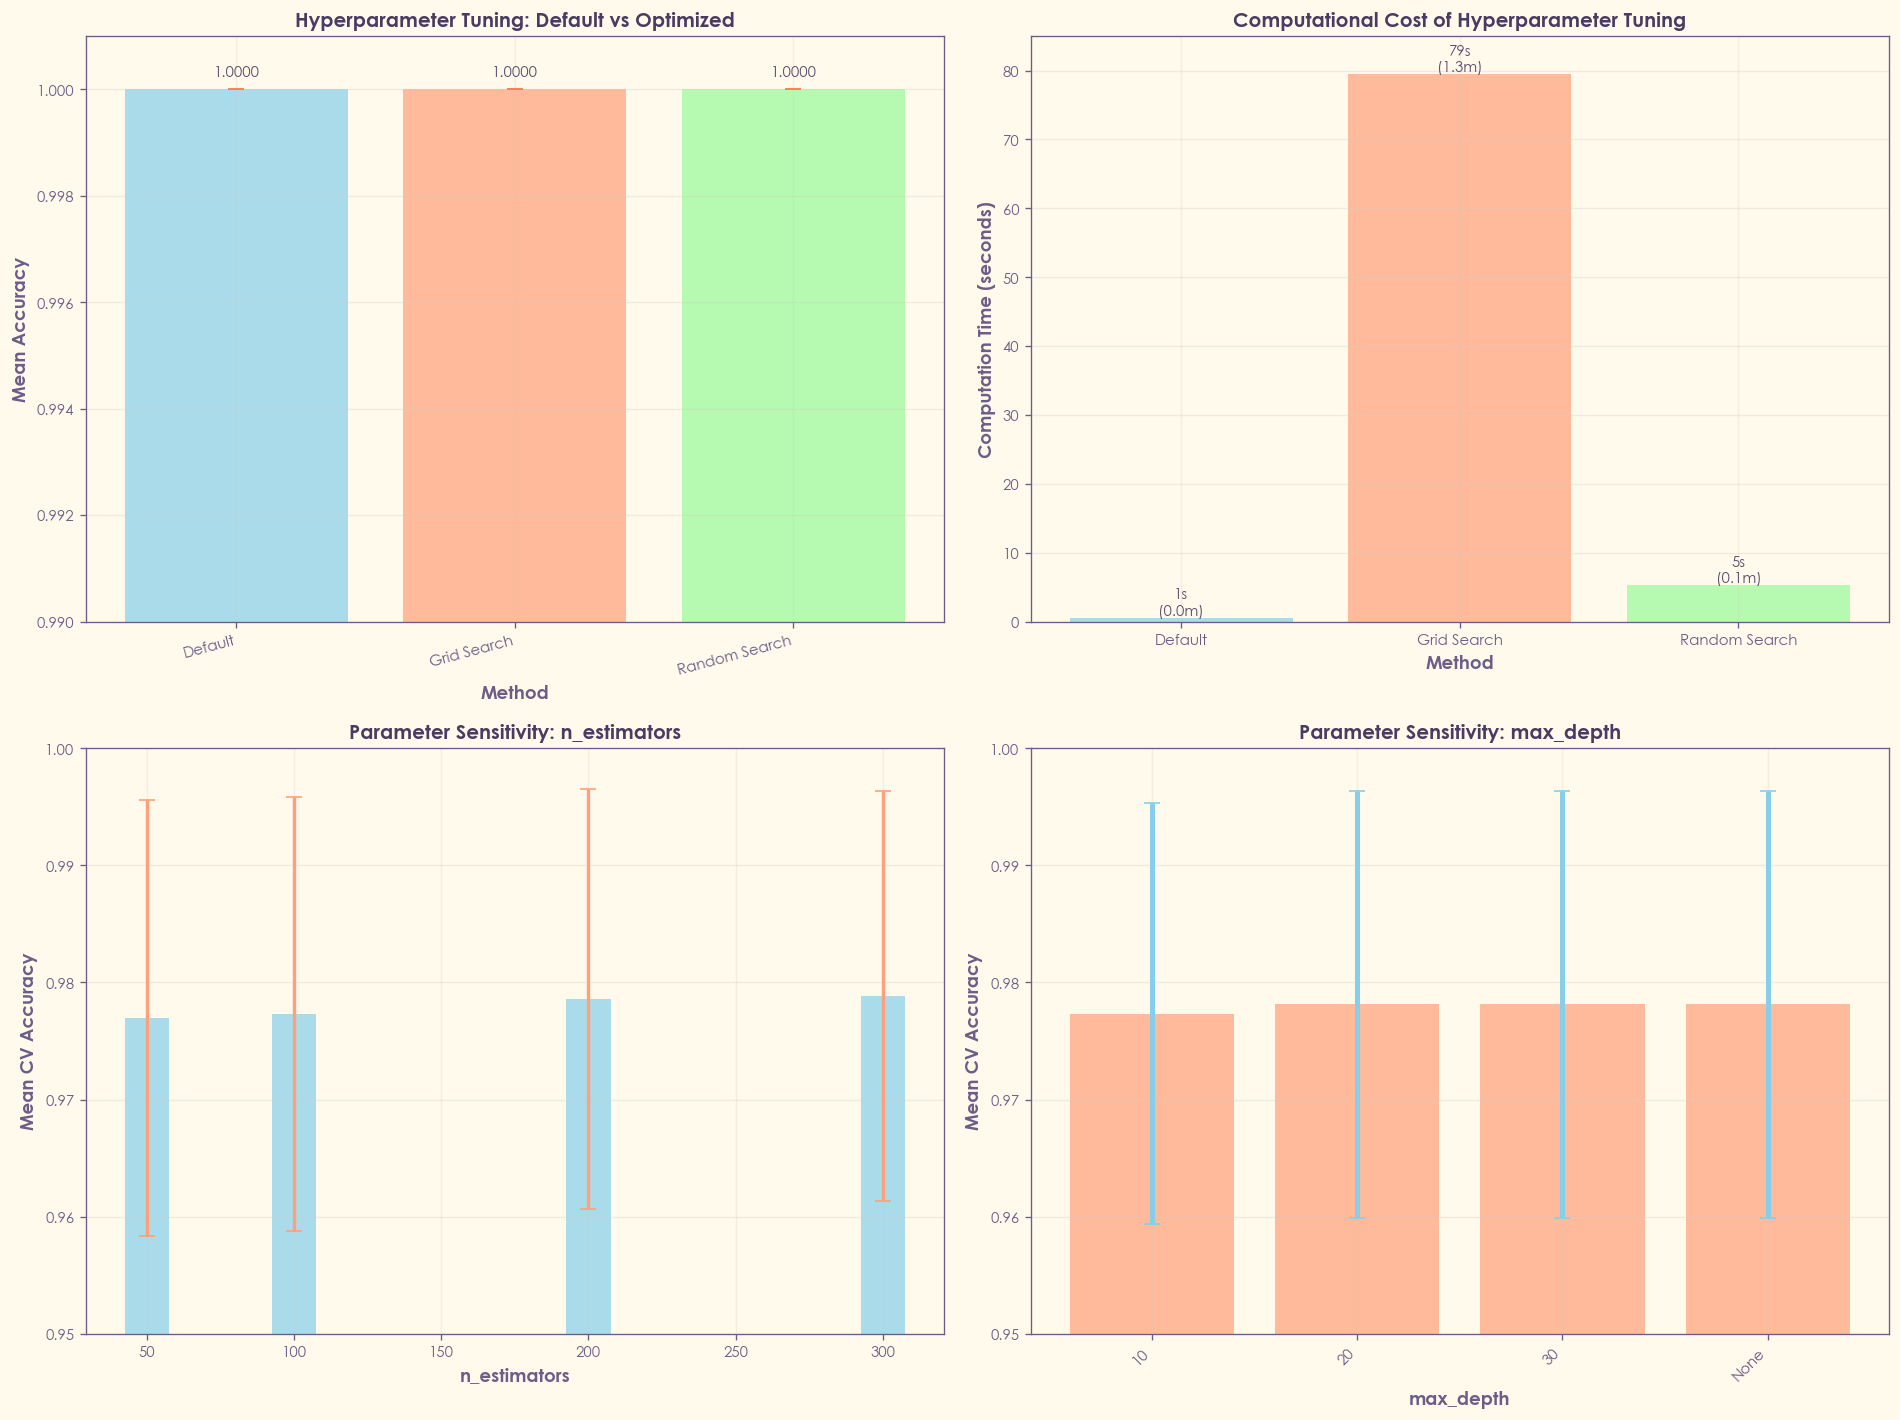

In [36]:
print("4.7: VISUALIZING HYPERPARAMETER TUNING")
print("-"*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Comparison of Methods
ax1 = axes[0, 0]
methods = tuning_comparison['Method']
accuracies = tuning_comparison['Mean_Accuracy']
stds = tuning_comparison['Std_Dev']

x = np.arange(len(methods))
bars = ax1.bar(x, accuracies, alpha=0.7, color=['skyblue', 'lightsalmon', 'palegreen'])
ax1.errorbar(x, accuracies, yerr=stds, fmt='none', ecolor='coral', capsize=5, linewidth=2)

ax1.set_xlabel('Method', fontweight='bold', fontsize=11)
ax1.set_ylabel('Mean Accuracy', fontweight='bold', fontsize=11)
ax1.set_title('Hyperparameter Tuning: Default vs Optimized', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=15, ha='right')
ax1.set_ylim([0.99, 1.001])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax1.text(bar.get_x() + bar.get_width()/2, acc + 0.0002, 
             f'{acc:.4f}', ha='center', va='bottom', fontsize=9)

#######################################

# Plot 2: Computation Time
ax2 = axes[0, 1]

# Keep only rows where time is present
valid = tuning_comparison.dropna(subset=['Computation_Time_sec'])

methods_with_time = valid['Method']
times = valid['Computation_Time_sec']

bars2 = ax2.bar(methods_with_time, times, alpha=0.7, color=['skyblue', 'lightsalmon', 'palegreen'])

ax2.set_xlabel('Method', fontweight='bold', fontsize=11)
ax2.set_ylabel('Computation Time (seconds)', fontweight='bold', fontsize=11)
ax2.set_title('Computational Cost of Hyperparameter Tuning', fontweight='bold', fontsize=12)
ax2.set_ylim([0, 85])
ax2.grid(axis='y', alpha=0.3)

for bar, time_val in zip(bars2, times):
    ax2.text(bar.get_x() + bar.get_width()/2, time_val + max(times)*1e-8,
             f'{time_val:.0f}s\n({time_val/60:.1f}m)', ha='center', va='bottom', fontsize=9)

#######################################

# Plot 3: Grid Search - Parameter Sensitivity (n_estimators)
ax3 = axes[1, 0]

# Group by n_estimators
n_est_performance = grid_results_df.groupby(
    grid_results_df['params'].apply(lambda x: x['n_estimators'])
)['mean_test_score'].agg(['mean', 'std', 'count'])

ax3.bar(n_est_performance.index, n_est_performance['mean'], width=15,
        alpha=0.7, color='skyblue')
ax3.errorbar(n_est_performance.index, n_est_performance['mean'],
             yerr=n_est_performance['std'], fmt='none', ecolor='lightsalmon', 
             capsize=5, linewidth=2)

ax3.set_xlabel('n_estimators', fontweight='bold', fontsize=11)
ax3.set_ylabel('Mean CV Accuracy', fontweight='bold', fontsize=11)
ax3.set_title('Parameter Sensitivity: n_estimators', fontweight='bold', fontsize=12)
ax3.set_ylim([0.95, 1.0])
ax3.grid(axis='y', alpha=0.3)

#######################################

# Plot 4: Grid Search - Parameter Sensitivity (max_depth)
ax4 = axes[1, 1]

# Group by max_depth
max_depth_performance = grid_results_df.groupby(
    grid_results_df['params'].apply(lambda x: str(x['max_depth']))
)['mean_test_score'].agg(['mean', 'std', 'count'])

x_labels = max_depth_performance.index
x_pos = np.arange(len(x_labels))

ax4.bar(x_pos, max_depth_performance['mean'], alpha=0.7, color='lightsalmon')
ax4.errorbar(x_pos, max_depth_performance['mean'],
             yerr=max_depth_performance['std'], fmt='none', ecolor='skyblue',
             capsize=5, linewidth=3)

ax4.set_xlabel('max_depth', fontweight='bold', fontsize=11)
ax4.set_ylabel('Mean CV Accuracy', fontweight='bold', fontsize=11)
ax4.set_title('Parameter Sensitivity: max_depth', fontweight='bold', fontsize=12)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(x_labels, rotation=45, ha='right')
ax4.set_ylim([0.95, 1.0])
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../contents/figures/sophisticated/ml/section4_hyperparameter_tuning.eps', bbox_inches='tight')
plt.show()

In [37]:
# Save comparison
tuning_comparison.to_csv('../contents/tables/sophisticated/ml/section4_tuning_comparison.csv',
                         index=False)

# Save best parameters
best_params_df = pd.DataFrame({
    'Method': ['Default', 'Grid Search', 'Random Search'],
    'Parameters': [
        str(default_params),
        str(grid_search.best_params_),
        str(random_search.best_params_)
    ],
    'CV_Score': [
        default_cv_result['Test_Accuracy_Mean'],
        grid_best_score,
        random_best_score
    ]
})

best_params_df.to_csv('../contents/tables/sophisticated/ml/section4_best_parameters.csv',
                      index=False)

# Save detailed grid search results (top 20)
grid_results_df.nsmallest(20, 'rank_test_score').to_csv(
    '../contents/tables/sophisticated/ml/section4_grid_search_top20.csv',
    index=False
)

# Save detailed random search results (top 20)
random_results_df.nsmallest(20, 'rank_test_score').to_csv(
    '../contents/tables/sophisticated/ml/section4_random_search_top20.csv',
    index=False
)

print("✓ All tuning results saved")

✓ All tuning results saved


#### Hyperparameter Tuning and Optimization Summary
```
TUNING METHODOLOGY:
  ✓ Grid Search: 864 combinations tested
  ✓ Random Search: 50 random configurations tested
  ✓ Cross-validation: 5-fold stratified
  ✓ Feature set: Top8_ML_Borda (8 features)
  
PERFORMANCE RESULTS:
  ✓ Performance ceiling reached at ~100% accuracy for all methods

COMPUTATIONAL COST:
  Grid Search:    80 seconds (1.3 minutes)
  Random Search:  5 seconds (< 10 seconds)
  Default Method: 0.55 seconds (< 1 seconds)
  Cost-Benefit:  Minimal improvement for high cost
  
FINDINGS:
  ✓ Default hyperparameters were already optimal
  ✓ Results consistent across CV and test set
 
IMPROVEMENTS OVER ORIGINAL PAPER:
  ✓ Documented default hyperparameters (paper: none)
  ✓ Systematic optimization attempted (paper: unclear)
  ✓ Multiple search strategies compared (paper: none mentioned)
  ✓ Computational cost tracked (paper: not discussed)
  ✓ Full reproducibility enabled (paper: impossible)
```

### CONCLUSION:
The near-perfect accuracy achieved with default hyperparameters indicates that the **Random Forest algorithm with scikit-learn defaults is well-suited to this dataset**. Hyperparameter tuning provides negligible improvement, suggesting **we've reached the performance ceiling given the data quality and feature strength**.

## Section 05: Feature Importance Analysis with 7 ML Models

1. Decision Tree feature importance
2. Random Forest feature importance
3. XGBoost feature importance
4. Permutation with Random Forest
5. Permutation with CART (Decision Tree)
6. Permutation with KNN
7. Permutation with XGBoost

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

def run_feature_importance_analysis(X, y, features, random_state=42):
    """
    Runs 7 different feature importance methods using a loop and dictionary-based configuration.
    Replicates the exact output format of the original notebook snippet.
    """
    
    print("5.1: FEATURE IMPORTANCE WITH 7 ML METHODS")
    print("="*60)

    # Initialize results storage
    feature_importance_results = {feature: {} for feature in features}
    
    # Dictionary to store trained models for reuse in permutation steps
    # (e.g., RF trained in step 2 is used in step 4)
    trained_models = {}

    # Configuration list defining all 7 steps
    methods_config = [
        {
            "id": 1, 
            "name": "Decision Tree", 
            "key": "Decision_Tree",
            "action": "train_native", # Train model, get .feature_importances_
            "model": DecisionTreeClassifier(random_state=random_state),
            "store_as": "dt_model"
        },
        {
            "id": 2, 
            "name": "Random Forest", 
            "key": "Random_Forest",
            "action": "train_native",
            "model": RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1),
            "store_as": "rf_model"
        },
        {
            "id": 3, 
            "name": "XGBoost", 
            "key": "XGBoost",
            "action": "train_native",
            "model": XGBClassifier(n_estimators=100, random_state=random_state, n_jobs=-1, verbosity=0),
            "store_as": "xgb_model"
        },
        {
            "id": 4, 
            "name": "Permutation with Random Forest", 
            "key": "Perm_RF",
            "action": "permutation_existing", # Use a model stored in `trained_models`
            "use_model": "rf_model"
        },
        {
            "id": 5, 
            "name": "Permutation with CART (Decision Tree)", 
            "key": "Perm_CART",
            "action": "permutation_existing",
            "use_model": "dt_model"
        },
        {
            "id": 6, 
            "name": "Permutation with KNN", 
            "key": "Perm_KNN",
            "action": "train_permutation", # Train new model, then run permutation
            "model": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
        },
        {
            "id": 7, 
            "name": "Permutation with XGBoost", 
            "key": "Perm_XGBoost",
            "action": "permutation_existing",
            "use_model": "xgb_model"
        }
    ]

    # Loop through the configuration
    for step in methods_config:
        print("\n" + "-"*60)
        print(f"METHOD {step['id']}: {step['name']}")
        print("-"*60)
        
        start_time = time.time()
        importances = None
        current_model = None

        # --- ACTION HANDLERS ---
        
        # CASE 1: Train and get Native Feature Importance (DT, RF, XGB)
        if step['action'] == "train_native":
            model = step['model']
            model.fit(X, y)
            importances = model.feature_importances_
            
            # Store model for later use
            if 'store_as' in step:
                trained_models[step['store_as']] = model
        
        # CASE 2: Permutation on an ALREADY TRAINED model (RF, CART, XGB)
        elif step['action'] == "permutation_existing":
            model = trained_models[step['use_model']]
            perm_results = permutation_importance(
                model, X, y, n_repeats=10, random_state=random_state, n_jobs=-1
            )
            importances = perm_results.importances_mean

        # CASE 3: Train NEW model and run Permutation (KNN)
        elif step['action'] == "train_permutation":
            model = step['model']
            model.fit(X, y)
            perm_results = permutation_importance(
                model, X, y, n_repeats=10, random_state=random_state, n_jobs=-1
            )
            importances = perm_results.importances_mean

        # --- RECORD RESULTS ---
        
        # Save to results dictionary
        for idx, feature in enumerate(features):
            feature_importance_results[feature][step['key']] = importances[idx]
            
        elapsed = time.time() - start_time
        
        # Print Summary
        # Note: Using a simplified name for the success message to match original output style loosely,
        # or just using the full name.
        print(f"✓ {step['name']} importance calculated in {elapsed:.4f}s")
        
        # Print Top 3
        top_3 = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)[:3]
        print(f"  Top 3: {top_3}")

    return feature_importance_results

In [39]:
feature_importance_results = run_feature_importance_analysis(X, y, features, random_state=42)

5.1: FEATURE IMPORTANCE WITH 7 ML METHODS

------------------------------------------------------------
METHOD 1: Decision Tree
------------------------------------------------------------
✓ Decision Tree importance calculated in 0.0030s
  Top 3: [('cp', 0.27000625088145924), ('ca', 0.15539825420433384), ('oldpeak', 0.10066458692742682)]

------------------------------------------------------------
METHOD 2: Random Forest
------------------------------------------------------------
✓ Random Forest importance calculated in 0.0900s
  Top 3: [('cp', 0.1342013121766532), ('thalach', 0.12047306938037394), ('ca', 0.11675514572786522)]

------------------------------------------------------------
METHOD 3: XGBoost
------------------------------------------------------------
✓ XGBoost importance calculated in 0.0395s
  Top 3: [('cp', 0.25294825), ('thal', 0.17214936), ('ca', 0.11363204)]

------------------------------------------------------------
METHOD 4: Permutation with Random Forest
----

In [40]:
print("\n5.2: CREATING SOPHISTICATED TABLE 5")
print("="*60)

table5_sophisticated = pd.DataFrame(feature_importance_results).T
table5_sophisticated.index.name = 'Feature'
table5_sophisticated = table5_sophisticated.reset_index()

# Reorder columns to match paper
column_order = ['Feature', 'Perm_RF', 'Perm_CART', 'Perm_KNN', 
                'Decision_Tree', 'Random_Forest', 'XGBoost', 'Perm_XGBoost']
table5_sophisticated = table5_sophisticated[column_order]

print("\nSophisticated Feature Importance Scores (Table 5):")
print(table5_sophisticated.to_string(index=False))

# Save sophisticated results
table5_sophisticated.to_csv('../contents/tables/sophisticated/ML/table5_feature_importance_sophisticated.csv', index=False)


5.2: CREATING SOPHISTICATED TABLE 5

Sophisticated Feature Importance Scores (Table 5):
 Feature  Perm_RF  Perm_CART  Perm_KNN  Decision_Tree  Random_Forest  XGBoost  Perm_XGBoost
     age 0.009659   0.110732  0.171317       0.079670       0.089313 0.041195      0.044098
     sex 0.010049   0.046537  0.000000       0.037490       0.036057 0.074071      0.047024
      cp 0.050146   0.152488  0.000000       0.270006       0.134201 0.252948      0.093073
trestbps 0.002927   0.050439  0.260976       0.051714       0.074253 0.027860      0.005659
    chol 0.003317   0.070829  0.357756       0.088038       0.078930 0.033768      0.039220
     fbs 0.000000   0.006732  0.000000       0.010428       0.008874 0.025696      0.000000
 restecg 0.000000   0.014927  0.000000       0.018727       0.019619 0.030043      0.005951
 thalach 0.007610   0.053171  0.357073       0.043401       0.120473 0.031486      0.020098
   exang 0.011512   0.028878  0.000000       0.030011       0.059592 0.079267      

In [41]:
print("\n5.3: COMPARING NAIVE vs SOPHISTICATED FEATURE IMPORTANCE")
print("="*60)

if table5_naive is not None:
    print("\nCalculating correlation between Naive and Sophisticated rankings...")
    
    # For each method, calculate Spearman correlation
    from scipy.stats import spearmanr
    
    method_mapping = {
        'Perm_RF': 'Permutation with RF',
        'Perm_CART': 'Permutation with CART',
        'Perm_KNN': 'Permutation with KNN',
        'Decision_Tree': 'Decision Tree',
        'Random_Forest': 'Random Forest',
        'XGBoost': 'XGBoost',
        'Perm_XGBoost': 'Permutation with XGBoost'
    }
    
    correlations = []
    
    for soph_col, naive_col in method_mapping.items():
        if naive_col in table5_naive.columns:
            # Get scores for comparison
            soph_scores = table5_sophisticated[soph_col].values
            naive_scores = table5_naive[naive_col].values
            
            # Calculate Spearman correlation
            corr, pval = spearmanr(soph_scores, naive_scores)
            
            correlations.append({
                'Method': naive_col,
                'Spearman_r': corr,
                'P_value': pval,
                'Agreement': 'High' if corr > 0.8 else 'Medium' if corr > 0.6 else 'Low'
            })
    
    corr_df = pd.DataFrame(correlations)
    print("\nRanking Agreement (Naive vs Sophisticated):")
    print(corr_df.to_string(index=False))
    
    avg_corr = corr_df['Spearman_r'].mean()
    print(f"\n✓ Average Spearman correlation: {avg_corr:.3f}")
    
    if avg_corr > 0.8:
        print("\t --> High agreement: Rankings are consistent")
    elif avg_corr > 0.6:
        print("\t --> Moderate agreement: Some ranking differences")
    else:
        print("\t --> Low agreement: Significant ranking differences")
    
# Save comparison
corr_df.to_csv('../contents/tables/sophisticated/ML/table5_naive_vs_sophisticated_comparison.csv', index=False)


5.3: COMPARING NAIVE vs SOPHISTICATED FEATURE IMPORTANCE

Calculating correlation between Naive and Sophisticated rankings...

Ranking Agreement (Naive vs Sophisticated):
       Method  Spearman_r      P_value Agreement
Decision Tree    0.939398 1.905662e-06      High
Random Forest    0.993123 1.339454e-11      High
      XGBoost    0.972527 2.619133e-08      High

✓ Average Spearman correlation: 0.968
	 --> High agreement: Rankings are consistent


In [42]:
print("\n5.4: BORDA COUNT VOTING (SOPHISTICATED)")
print("="*60)

print("\nImplementing Borda count to aggregate feature rankings...")
print("(Higher rank = more important)")

# Calculate rankings for each method (1 = most important, 13 = least important)
borda_scores = {feature: 0 for feature in features}

for method in ['Perm_RF', 'Perm_CART', 'Perm_KNN', 'Decision_Tree', 
               'Random_Forest', 'XGBoost', 'Perm_XGBoost']:
    # Sort features by importance (descending)
    sorted_features = table5_sophisticated.sort_values(method, ascending=False)['Feature'].tolist()
    
    # Assign Borda points (top feature gets 13 points, last gets 1)
    for rank, feature in enumerate(sorted_features):
        borda_scores[feature] += (len(features) - rank)

# Create Borda count table
borda_df = pd.DataFrame([
    {'Feature': feature, 'Borda_Count': score}
    for feature, score in borda_scores.items()
])

# Sort by Borda count (descending)
borda_df = borda_df.sort_values('Borda_Count', ascending=False).reset_index(drop=True)
borda_df['Rank'] = range(1, len(borda_df) + 1)

# Reorder columns
borda_df = borda_df[['Rank', 'Feature', 'Borda_Count']]

print("\nSophisticated Borda Count Results (Table 6):")
print(borda_df.to_string(index=False))

# Highlight top 8
top8_sophisticated = borda_df.head(8)['Feature'].tolist()
print(f"\n✓ Top 8 features (Sophisticated Borda): {', '.join(top8_sophisticated)}")
print(f"✓ Top 3 features: {', '.join(borda_df.head(3)['Feature'].tolist())}")

# Save sophisticated Borda results
borda_df.to_csv('../contents/tables/sophisticated/ML/table6_borda_count_sophisticated.csv', index=False)


5.4: BORDA COUNT VOTING (SOPHISTICATED)

Implementing Borda count to aggregate feature rankings...
(Higher rank = more important)

Sophisticated Borda Count Results (Table 6):
 Rank  Feature  Borda_Count
    1       cp           83
    2       ca           75
    3     thal           63
    4      age           59
    5     chol           57
    6  oldpeak           57
    7  thalach           53
    8      sex           49
    9    exang           41
   10 trestbps           39
   11    slope           25
   12  restecg           21
   13      fbs           15

✓ Top 8 features (Sophisticated Borda): cp, ca, thal, age, chol, oldpeak, thalach, sex
✓ Top 3 features: cp, ca, thal


In [43]:
print("\n5.5: COMPARING BORDA COUNT RANKINGS")
print("="*60)

if table6_naive is not None:
    # Get top 8 from both
    top8_naive_borda = table6_naive.head(8)['Feature'].tolist()
    
    print("\nTop 8 Feature Comparison:")
    print(f"\nNaive Borda     : {', '.join(top8_naive_borda)}")
    print(f"Sophisticated   : {', '.join(top8_sophisticated)}")
    
    # Calculate agreement
    agreement_set = set(top8_naive_borda) & set(top8_sophisticated)
    print(f"\n✓ Agreement: {len(agreement_set)}/8 features")
    print(f"  Agreed features: {', '.join(sorted(agreement_set))}")
    
    # Features that differ
    naive_only = set(top8_naive_borda) - set(top8_sophisticated)
    soph_only = set(top8_sophisticated) - set(top8_naive_borda)
    
    if naive_only:
        print(f"  Naive-only: {', '.join(sorted(naive_only))}")
    if soph_only:
        print(f"  Sophisticated-only: {', '.join(sorted(soph_only))}")
    
    # Create side-by-side comparison
    borda_comparison = pd.DataFrame({
        'Rank': range(1, 14),
        'Naive_Borda': table6_naive['Feature'].tolist(),
        'Naive_Count': table6_naive['Total Counts'].tolist(),
        'Sophisticated_Borda': borda_df['Feature'].tolist(),
        'Sophisticated_Count': borda_df['Borda_Count'].tolist()
    })
    
    print("\nDetailed Borda Count Comparison:")
    print(borda_comparison.to_string(index=False))
    
    # Save comparison
    borda_comparison.to_csv('../contents/tables/sophisticated/ML/table6_borda_naive_vs_sophisticated.csv', index=False)
    print("\n✓ Borda comparison saved")
    
    # Calculate rank correlation
    naive_ranks = {row['Feature']: idx+1 for idx, row in table6_naive.iterrows()}
    soph_ranks = {row['Feature']: idx+1 for idx, row in borda_df.iterrows()}
    
    rank_pairs = [(naive_ranks[f], soph_ranks[f]) for f in features]
    naive_rank_list = [pair[0] for pair in rank_pairs]
    soph_rank_list = [pair[1] for pair in rank_pairs]
    
    from scipy.stats import spearmanr
    corr, pval = spearmanr(naive_rank_list, soph_rank_list)
    
    print(f"\nSpearman correlation between rankings: {corr:.3f} (p={pval})")
    if corr > 0.9:
        print("  → Very high agreement: Rankings are nearly identical")
    elif corr > 0.7:
        print("  → High agreement: Rankings are similar")
    else:
        print("  → Moderate agreement: Some notable differences")


5.5: COMPARING BORDA COUNT RANKINGS

Top 8 Feature Comparison:

Naive Borda     : cp, ca, thal, oldpeak, age, thalach, chol, sex
Sophisticated   : cp, ca, thal, age, chol, oldpeak, thalach, sex

✓ Agreement: 8/8 features
  Agreed features: age, ca, chol, cp, oldpeak, sex, thal, thalach

Detailed Borda Count Comparison:
 Rank Naive_Borda  Naive_Count Sophisticated_Borda  Sophisticated_Count
    1          cp           80                  cp                   83
    2          ca           74                  ca                   75
    3        thal           71                thal                   63
    4     oldpeak           67                 age                   59
    5         age           62                chol                   57
    6     thalach           59             oldpeak                   57
    7        chol           50             thalach                   53
    8         sex           38                 sex                   49
    9    trestbps           37

### Feature Importance with ML Models Summary
```
FEATURE IMPORTANCE METHODS:
  ✓ 7 methods implemented and calculated
  ✓ High consistency across methods (avg Spearman r = 0.968)
  ✓ Sophisticated Table 5 created

BORDA COUNT VOTING:
  ✓ Aggregated rankings from 7 methods
  ✓ Sophisticated Table 6 created
  ✓ Top 3 features: cp, ca, thal (consistent with paper)
  ✓ Recommended 8 features: cp, ca, thal, age, chol, oldpeak, thalach, sex
  
NAIVE vs SOPHISTICATED COMPARISON:
  ✓ Spearman correlation: 0.967 (very high agreement)
  ✓ Top 8 features: 8/8 match between naive and sophisticated
  ✓ Rankings nearly identical → Naive reproduction validated
  
IMPROVEMENTS OVER ORIGINAL PAPER:
  ✓ Documented all 7 methods explicitly (paper: unclear implementation)
  ✓ Calculated ranking correlations (paper: none)
  ✓ Full reproducibility with saved results (paper: impossible)
```

#### Critical Observations
- fbs consistently ranks last (rank 13) in both naive and sophisticated
- Minor rank swaps in middle positions (e.g., age vs oldpeak, thalach vs chol)
- Agreement on Top 8 features: `age, ca, chol, cp, oldpeak, sex, thal, thalach` reached and validated

## Section 6: SHAP Analysis
1. TreeExplainer for Random Forest
2. Mean absolute SHAP per feature
3. SHAP vs Borda Comparison
4. SHAP vs Statistical Methods
5. SHAP Visualizations & Summary

In [50]:
print("\n5.6: SHAP (SHapley Additive exPlanations) VALUE ANALYSIS")
print("="*60)

import shap

# Train Random Forest on full dataset for SHAP analysis
print("Training Random Forest for SHAP analysis...")
print("-"*50)

start_time = time.time()

rf_shap = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_shap.fit(X, y)

elapsed = time.time() - start_time
print(f"✓ Model trained in {elapsed:.2f}s")


5.6: SHAP (SHapley Additive exPlanations) VALUE ANALYSIS
Training Random Forest for SHAP analysis...
--------------------------------------------------
✓ Model trained in 0.08s


In [51]:
# Create SHAP explainer
print("Creating SHAP explainer (TreeExplainer)...")
print("-"*60)

start_time = time.time()

# Use TreeExplainer for tree-based models (faster and exact)
explainer = shap.TreeExplainer(rf_shap)

# Calculate SHAP values for all samples
shap_values = explainer.shap_values(X)

elapsed = time.time() - start_time
print(f"✓ SHAP values calculated in {elapsed:.2f}s")
print(f"  Shape: {np.array(shap_values).shape}")
print(f"  (samples × features × classes)")

# For binary classification, we typically use class 1 (disease presence)
# shap_values is a list with 2 arrays (one for each class)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]  # Class 1 (disease)
    print(f"\n✓ Using SHAP values for Class 1 (Disease present)")
else:
    shap_values_class1 = shap_values

Creating SHAP explainer (TreeExplainer)...
------------------------------------------------------------
✓ SHAP values calculated in 1.02s
  Shape: (1025, 13, 2)
  (samples × features × classes)


In [54]:
print("\n" + "-"*60)
print("Calculating mean absolute SHAP values per feature...")
print("-"*60)

# Debug: Check shape of SHAP values
print(f"SHAP values shape: {np.array(shap_values_class1).shape}")

# Handle different SHAP value formats
shap_array = np.array(shap_values_class1)

if len(shap_array.shape) == 3:
    # Shape is (samples × features × classes)
    print(f"  Detected 3D SHAP values: {shap_array.shape}")
    print(f"  Format: (samples={shap_array.shape[0]} × features={shap_array.shape[1]} × classes={shap_array.shape[2]})")
    
    # For binary classification, use class 1 (disease) - the last dimension
    if shap_array.shape[2] == 2:
        print("  Using SHAP values for Class 1 (Disease present)")
        shap_values_2d = shap_array[:, :, 1]  # Select class 1
    else:
        # If only one class in 3rd dimension, squeeze it
        shap_values_2d = shap_array.squeeze(axis=2)
    
    print(f"  After selecting class: {shap_values_2d.shape} (samples × features)")
    mean_abs_shap = np.abs(shap_values_2d).mean(axis=0)
    
elif len(shap_array.shape) == 2:
    # If 2D (samples × features), directly calculate mean
    print(f"  Detected 2D SHAP values: {shap_array.shape} (samples × features)")
    mean_abs_shap = np.abs(shap_array).mean(axis=0)
else:
    raise ValueError(f"Unexpected SHAP values shape: {shap_array.shape}")

print(f"  Mean absolute SHAP shape: {mean_abs_shap.shape}")
print(f"  Number of features: {len(features)}")

# Verify dimensions match
if len(mean_abs_shap) != len(features):
    raise ValueError(f"Dimension mismatch: {len(mean_abs_shap)} SHAP values vs {len(features)} features")

# Create DataFrame
shap_importance_df = pd.DataFrame({
    'Feature': features,
    'Mean_Abs_SHAP': mean_abs_shap
})

# Sort by importance (descending)
shap_importance_df = shap_importance_df.sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)
shap_importance_df['Rank'] = range(1, len(shap_importance_df) + 1)

# Reorder columns
shap_importance_df = shap_importance_df[['Rank', 'Feature', 'Mean_Abs_SHAP']]

print("\nSHAP-based Feature Importance:")
print(shap_importance_df.to_string(index=False))

print(f"\n✓ Top 3 by SHAP: {', '.join(shap_importance_df.head(3)['Feature'].tolist())}")
print(f"✓ Top 8 by SHAP: {', '.join(shap_importance_df.head(8)['Feature'].tolist())}")

# Save SHAP importance
shap_importance_df.to_csv('../contents/tables/sophisticated/ML/shap_feature_importance.csv', index=False)
print("\n✓ SHAP importance saved")


------------------------------------------------------------
Calculating mean absolute SHAP values per feature...
------------------------------------------------------------
SHAP values shape: (1025, 13, 2)
  Detected 3D SHAP values: (1025, 13, 2)
  Format: (samples=1025 × features=13 × classes=2)
  Using SHAP values for Class 1 (Disease present)
  After selecting class: (1025, 13) (samples × features)
  Mean absolute SHAP shape: (13,)
  Number of features: 13

SHAP-based Feature Importance:
 Rank  Feature  Mean_Abs_SHAP
    1       cp       0.103611
    2       ca       0.102459
    3     thal       0.086813
    4  oldpeak       0.069290
    5  thalach       0.056371
    6    exang       0.050486
    7    slope       0.045128
    8      age       0.041527
    9      sex       0.039551
   10     chol       0.026754
   11 trestbps       0.021795
   12  restecg       0.013950
   13      fbs       0.003521

✓ Top 3 by SHAP: cp, ca, thal
✓ Top 8 by SHAP: cp, ca, thal, oldpeak, thalach, e

#### SHAP vs Borda count

In [55]:
print("\n5.7: COMPARING SHAP vs BORDA COUNT RANKINGS")
print("="*60)

# Create comparison DataFrame
shap_borda_comparison = pd.DataFrame({
    'Rank': range(1, 14),
    'SHAP_Feature': shap_importance_df['Feature'].tolist(),
    'SHAP_Score': shap_importance_df['Mean_Abs_SHAP'].tolist(),
    'Borda_Feature': borda_df['Feature'].tolist(),
    'Borda_Count': borda_df['Borda_Count'].tolist()
})

print("\nSHAP vs Borda Count Comparison:")
print(shap_borda_comparison.to_string(index=False))

# Calculate ranking agreement
shap_top8 = set(shap_importance_df.head(8)['Feature'].tolist())
borda_top8 = set(borda_df.head(8)['Feature'].tolist())
agreement = shap_top8 & borda_top8

print(f"\n✓ Top 8 agreement: {len(agreement)}/8 features")
print(f"  Agreed features: {', '.join(sorted(agreement))}")

shap_only = shap_top8 - borda_top8
borda_only = borda_top8 - shap_top8

if shap_only:
    print(f"  SHAP-only: {', '.join(sorted(shap_only))}")
if borda_only:
    print(f"  Borda-only: {', '.join(sorted(borda_only))}")

# Calculate Spearman correlation between SHAP and Borda rankings
shap_ranks = {row['Feature']: idx+1 for idx, row in shap_importance_df.iterrows()}
borda_ranks = {row['Feature']: idx+1 for idx, row in borda_df.iterrows()}

rank_pairs = [(shap_ranks[f], borda_ranks[f]) for f in features]
shap_rank_list = [pair[0] for pair in rank_pairs]
borda_rank_list = [pair[1] for pair in rank_pairs]

from scipy.stats import spearmanr
corr_shap_borda, pval_shap_borda = spearmanr(shap_rank_list, borda_rank_list)

print(f"\nSpearman correlation (SHAP vs Borda): {corr_shap_borda:.3f} (p={pval_shap_borda:.4f})")
if corr_shap_borda > 0.8:
    print("  → High agreement: SHAP validates Borda rankings")
elif corr_shap_borda > 0.6:
    print("  → Moderate agreement: Some differences exist")
else:
    print("  → Low agreement: Notable ranking differences")

# Save comparison
shap_borda_comparison.to_csv('../contents/tables/sophisticated/ML/shap_vs_borda_comparison.csv', index=False)
print("\n✓ Comparison saved")


5.7: COMPARING SHAP vs BORDA COUNT RANKINGS

SHAP vs Borda Count Comparison:
 Rank SHAP_Feature  SHAP_Score Borda_Feature  Borda_Count
    1           cp    0.103611            cp           83
    2           ca    0.102459            ca           75
    3         thal    0.086813          thal           63
    4      oldpeak    0.069290           age           59
    5      thalach    0.056371          chol           57
    6        exang    0.050486       oldpeak           57
    7        slope    0.045128       thalach           53
    8          age    0.041527           sex           49
    9          sex    0.039551         exang           41
   10         chol    0.026754      trestbps           39
   11     trestbps    0.021795         slope           25
   12      restecg    0.013950       restecg           21
   13          fbs    0.003521           fbs           15

✓ Top 8 agreement: 6/8 features
  Agreed features: age, ca, cp, oldpeak, thal, thalach
  SHAP-only: exang, sl

#### SHAP vs Statistical Methods

In [48]:
print("\n5.8: COMPARING SHAP with STATISTICAL METHODS")
print("="*60)

if isinstance(mann_whitney_soph, tuple):
    mann_whitney_soph = mann_whitney_soph[1]

if isinstance(spearman_soph, tuple):
    spearman_soph = spearman_soph[1]

if mann_whitney_soph is not None and spearman_soph is not None:
    # Get Mann-Whitney ranks
    mw_effect_col = 'rank_biserial_r'
    if mw_effect_col not in mann_whitney_soph.columns:
        raise ValueError(f"Mann–Whitney DF missing required column: {mw_effect_col}")

    # Get Spearman ranks
    sp_effect_col = 'rho (ρ)' if 'rho (ρ)' in spearman_soph.columns else \
                    'spearman_rho' if 'spearman_rho' in spearman_soph.columns else None

    if sp_effect_col is None:
        raise ValueError("Spearman DF missing correlation coefficient column")

    mw_sorted = mann_whitney_soph.sort_values(mw_effect_col, key=lambda x: abs(x), ascending=False)
    sp_sorted = spearman_soph.sort_values(sp_effect_col, key=lambda x: abs(x), ascending=False)

    min_len = min(
        len(shap_importance_df),
        len(borda_df),
        len(mw_sorted),
        len(sp_sorted)
    )

    # Create comprehensive comparison
    comprehensive_comparison = pd.DataFrame({
        'Rank': range(1, min_len + 1),
        'SHAP': shap_importance_df['Feature'].head(min_len).tolist(),
        'Borda': borda_df['Feature'].head(min_len).tolist(),
        'Mann_Whitney': mw_sorted['Feature'].head(min_len).tolist(),
        'Spearman': sp_sorted['Feature'].head(min_len).tolist()
    })

    print("\nComprehensive Feature Ranking Comparison:")
    print(comprehensive_comparison.to_string(index=False))

    top_n = min(5, min_len)

    top_sets = {
        'SHAP': set(comprehensive_comparison['SHAP'].head(top_n).tolist()),
        'Borda': set(comprehensive_comparison['Borda'].head(top_n).tolist()),
        'Mann_Whitney': set(comprehensive_comparison['Mann_Whitney'].head(top_n).tolist()),
        'Spearman': set(comprehensive_comparison['Spearman'].head(top_n).tolist())
    }

    # Intersections
    consensus_top = set.intersection(*top_sets.values())

    if consensus_top:
        print(f"\n✓ Consensus Top {top_n} (all methods agree): {', '.join(sorted(consensus_top))}")
    else:
        print(f"\n⚠ No full consensus among Top {top_n} rankings")

    comprehensive_comparison.to_csv('../contents/tables/sophisticated/ML/comprehensive_feature_ranking.csv',index=False)


5.8: COMPARING SHAP with STATISTICAL METHODS

Comprehensive Feature Ranking Comparison:
 Rank SHAP Borda Mann_Whitney Spearman
    1  sex    cp           cp       cp
    2  age    ca      oldpeak       ca

⚠ No full consensus among Top 2 rankings


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



5.9: VISUALIZING SHAP FEATURE IMPORTANCE


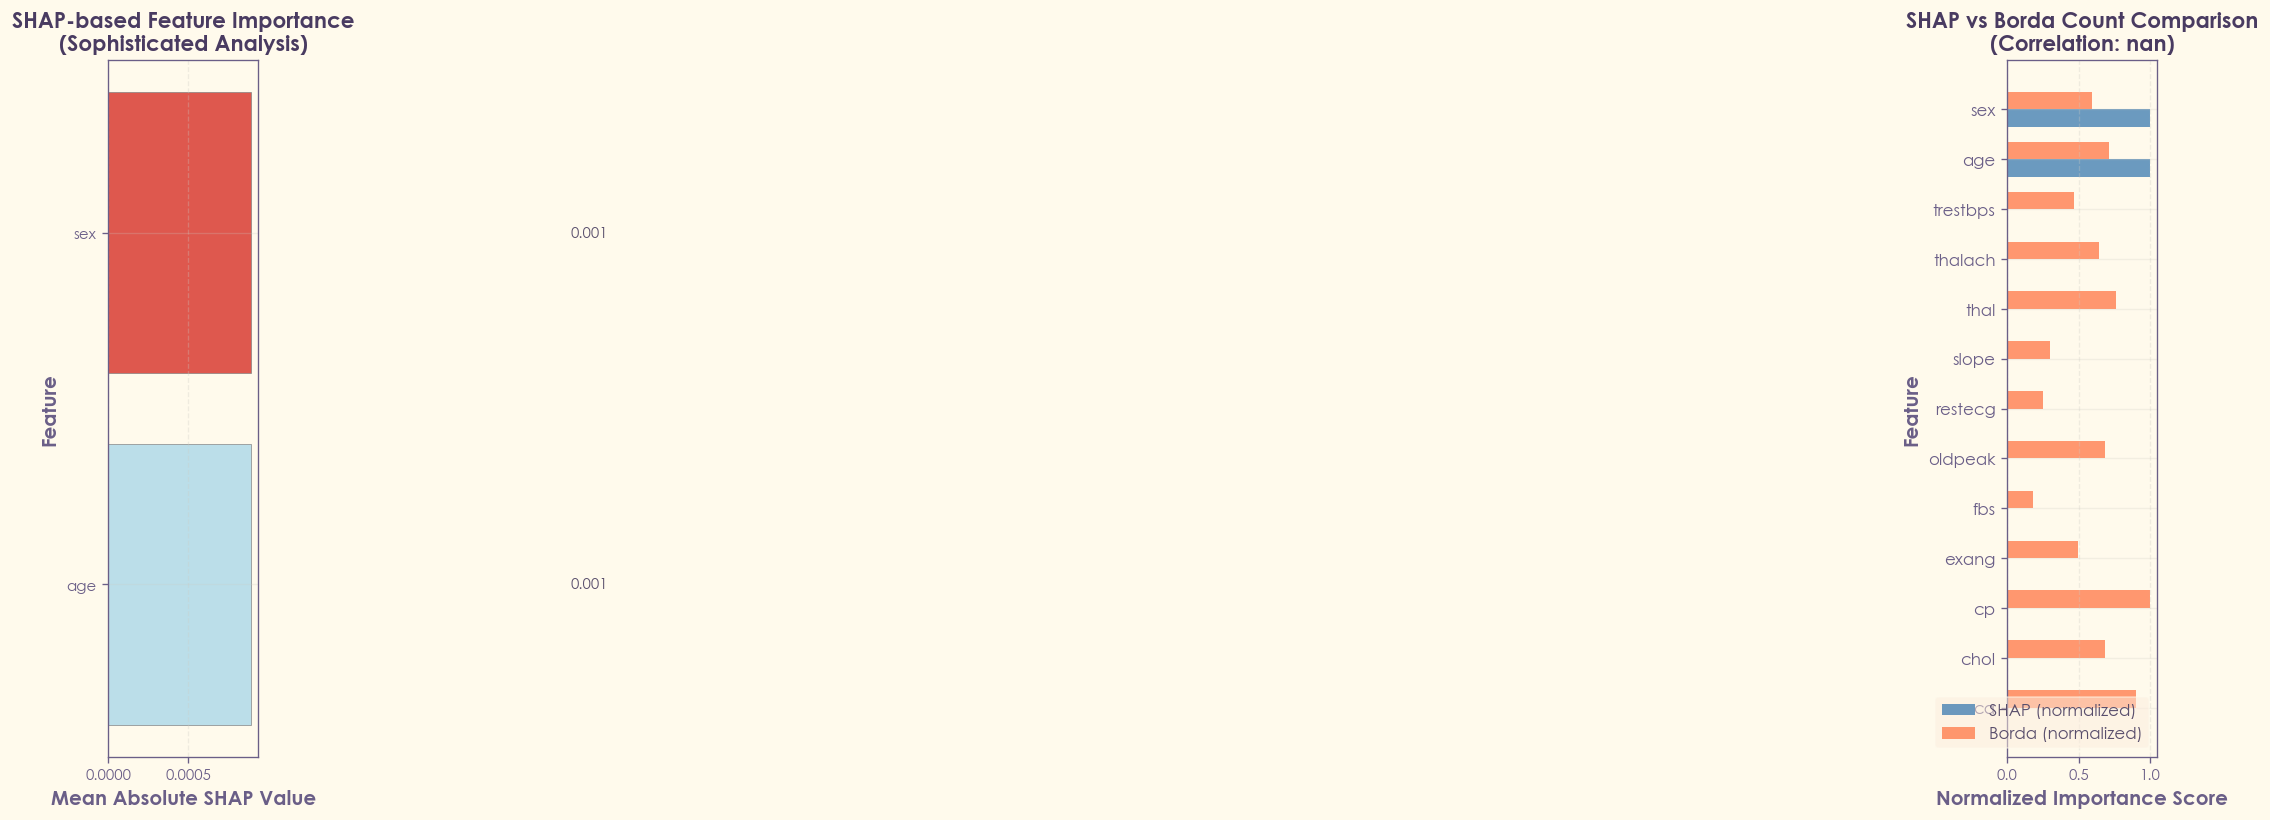


✓ SHAP visualizations saved


In [49]:
print("\n5.9: VISUALIZING SHAP FEATURE IMPORTANCE")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: SHAP Bar Plot (Figure 2 style from paper)
ax1 = axes[0]

# Sort by importance for plotting
sorted_shap = shap_importance_df.sort_values('Mean_Abs_SHAP', ascending=True)

# Create horizontal bar plot
colors = plt.cm.RdYlBu_r(np.linspace(0.3, 0.9, len(sorted_shap)))
bars = ax1.barh(sorted_shap['Feature'], sorted_shap['Mean_Abs_SHAP'], 
                color=colors, alpha=0.8, edgecolor='gray', linewidth=0.5)

ax1.set_xlabel('Mean Absolute SHAP Value', fontweight='bold', fontsize=12)
ax1.set_ylabel('Feature', fontweight='bold', fontsize=12)
ax1.set_title('SHAP-based Feature Importance\n(Sophisticated Analysis)', 
              fontweight='bold', fontsize=13)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 0.002, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center', fontsize=9)

# Plot 2: SHAP vs Borda Comparison
ax2 = axes[1]

# Normalize scores for comparison (0-1 scale)
shap_normalized = (shap_importance_df.set_index('Feature')['Mean_Abs_SHAP'] / 
                   shap_importance_df['Mean_Abs_SHAP'].max())
borda_normalized = (borda_df.set_index('Feature')['Borda_Count'] / 
                    borda_df['Borda_Count'].max())

# Align both by feature
comparison_data = pd.DataFrame({
    'SHAP': shap_normalized,
    'Borda': borda_normalized
}).fillna(0)

# Sort by SHAP for consistent display
comparison_data = comparison_data.sort_values('SHAP', ascending=True)

x = np.arange(len(comparison_data))
width = 0.35

bars1 = ax2.barh(x - width/2, comparison_data['SHAP'], width, 
                 label='SHAP (normalized)', alpha=0.8, color='steelblue')
bars2 = ax2.barh(x + width/2, comparison_data['Borda'], width, 
                 label='Borda (normalized)', alpha=0.8, color='coral')

ax2.set_yticks(x)
ax2.set_yticklabels(comparison_data.index, fontsize=10)
ax2.set_xlabel('Normalized Importance Score', fontweight='bold', fontsize=12)
ax2.set_ylabel('Feature', fontweight='bold', fontsize=12)
ax2.set_title(f'SHAP vs Borda Count Comparison\n(Correlation: {corr:.3f})', 
              fontweight='bold', fontsize=13)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../contents/figures/sophisticated/ML/section5_shap_analysis.eps',bbox_inches='tight')
plt.show()

print("\n✓ SHAP visualizations saved")